# ADI/CV-Based Sequential Training for Hybrid Forecasting Models

This notebook reads a sales CSV or Excel file, classifies each product using **ADI / CV² demand classification**, then trains the correct hybrid forecasting model:

- `ARIMA + XGBoost` for `SMOOTH` and `ERRATIC` demand
- `TSB + XGBoost` for `INTERMITTENT` and `LUMPY` demand

Training schedule used in this notebook:
- `ARIMA` and `TSB` use **rolling walk-forward epochs** because they are statistical time-series models, not neural networks
- The notebook evaluates up to the last `12` monthly observations per product as the recommended walk-forward window for these models
- `XGBoost` training rounds are taken from the actual model configuration via `n_estimators`
- Current configured XGBoost rounds in this project are `200` for the initial fit and `400` for retraining

Reported metrics:
- `RMSE`
- `MSE`
- `MAE`
- `MAPE`

In [1]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().resolve().parents[1]
PYTHON_ROOT = PROJECT_ROOT / "python"
MODELS_DIR = PYTHON_ROOT / "models"
UTILS_DIR = PYTHON_ROOT / "utils"
OUTPUT_DIR = PYTHON_ROOT / "trained_models"
TRAINED_MODELS_DIR = PYTHON_ROOT / "trained_models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TRAINED_MODELS_DIR.mkdir(parents=True, exist_ok=True)

for path in [MODELS_DIR, UTILS_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from arima_xgb_model import train_model as train_arima_xgb, save_trained_model as save_arima_xgb_model
from arima_xgb_model import forecast_from_artifact as forecast_arima_xgb
from arima_xgb_model import XGB_PARAMS_INITIAL as ARIMA_XGB_PARAMS_INITIAL, XGB_PARAMS_RETRAIN as ARIMA_XGB_PARAMS_RETRAIN
from tsb_xgb_model import train_model as train_tsb_xgb, save_trained_model as save_tsb_xgb_model
from tsb_xgb_model import forecast_from_artifact as forecast_tsb_xgb
from tsb_xgb_model import XGB_PARAMS_INITIAL as TSB_XGB_PARAMS_INITIAL, XGB_PARAMS_RETRAIN as TSB_XGB_PARAMS_RETRAIN
from demand_classifier import classify

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
METRIC_COLUMNS = ["RMSE", "MSE", "MAE", "MAPE"]

## Configure Data Source

Point these settings to your sales file. If `TARGET_PRODUCTS = None`, the notebook will classify and train **all products** found in the file.

In [2]:
DATA_PATH = PROJECT_ROOT / "python" / "data" / "revised_sales_2.csv"
SHEET_NAME = 0

DATE_COLUMN = "reportDate"
QUANTITY_COLUMN = "quantity"
PRODUCT_COLUMN = "productName"
TOTAL_AMOUNT_COLUMN = "totalAmount"

TARGET_PRODUCTS = None
INCLUDE_BUSINESS_REVENUE = True
BUSINESS_ID = 1
BUSINESS_REVENUE_NAME = "Business Total Revenue"
BUSINESS_REVENUE_ARTIFACT_NAME = "monthly_total_revenue"

# Example: TARGET_PRODUCTS = ["Brake Pad", "Oil Filter"]

MIN_TRAIN_SIZE = 12
MAX_WALK_FORWARD_EPOCHS = 12
FORECAST_HORIZON = 6
TOP_PRODUCTS_TO_PLOT = 5

DATA_PATH

WindowsPath('C:/Users/Joem Inciong/automotive-spare-parts-dss-thesis/autoparts-backend/python/data/revised_sales_2.csv')

In [3]:
def slugify_name(value):
    slug = re.sub(r"[^a-z0-9]+", "_", str(value).strip().lower()).strip("_")
    return slug or "forecast_model"


def recommended_walk_forward_epochs(n_observations, min_train_size=12, max_walk_forward_epochs=12):
    available = max(0, int(n_observations) - int(min_train_size))
    return max(1, min(available, int(max_walk_forward_epochs)))


def load_sales_data(data_path, sheet_name=0):
    data_path = Path(data_path)
    if not data_path.exists():
        raise FileNotFoundError(f"Sales data file not found: {data_path}")

    if data_path.suffix.lower() == ".csv":
        df = pd.read_csv(data_path)
    elif data_path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(data_path, sheet_name=sheet_name)
    else:
        raise ValueError("DATA_PATH must be a CSV or Excel file.")

    required_columns = [DATE_COLUMN, QUANTITY_COLUMN, PRODUCT_COLUMN]
    missing = [column for column in required_columns if column not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    working = df.copy()
    if TARGET_PRODUCTS is not None:
        target_set = {str(item) for item in TARGET_PRODUCTS}
        working = working[working[PRODUCT_COLUMN].astype(str).isin(target_set)]

    if working.empty:
        raise ValueError("No sales rows matched the current product filter.")

    working[DATE_COLUMN] = pd.to_datetime(working[DATE_COLUMN])
    working[QUANTITY_COLUMN] = pd.to_numeric(working[QUANTITY_COLUMN], errors="coerce").fillna(0.0)
    working[PRODUCT_COLUMN] = working[PRODUCT_COLUMN].astype(str).str.strip()
    working["period"] = working[DATE_COLUMN].dt.to_period("M")

    monthly = (
        working.groupby([PRODUCT_COLUMN, "period"], as_index=False)[QUANTITY_COLUMN]
        .sum()
        .sort_values([PRODUCT_COLUMN, "period"])
        .reset_index(drop=True)
    )

    monthly["period_str"] = monthly["period"].astype(str)
    monthly[QUANTITY_COLUMN] = monthly[QUANTITY_COLUMN].astype(float)
    return monthly




def load_business_revenue_series(data_path, sheet_name=0):
    data_path = Path(data_path)
    if data_path.suffix.lower() == ".csv":
        df = pd.read_csv(data_path)
    elif data_path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(data_path, sheet_name=sheet_name)
    else:
        raise ValueError("DATA_PATH must be a CSV or Excel file.")

    required_columns = [DATE_COLUMN, TOTAL_AMOUNT_COLUMN]
    missing = [column for column in required_columns if column not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns for company revenue: {missing}")

    working = df.copy()
    working[DATE_COLUMN] = pd.to_datetime(working[DATE_COLUMN])
    working[TOTAL_AMOUNT_COLUMN] = pd.to_numeric(working[TOTAL_AMOUNT_COLUMN], errors="coerce").fillna(0.0)
    working["period"] = working[DATE_COLUMN].dt.to_period("M")

    revenue = (
        working.groupby("period", as_index=False)[TOTAL_AMOUNT_COLUMN]
        .sum()
        .sort_values("period")
        .reset_index(drop=True)
    )

    revenue[PRODUCT_COLUMN] = BUSINESS_REVENUE_NAME
    revenue[QUANTITY_COLUMN] = revenue[TOTAL_AMOUNT_COLUMN].astype(float)
    revenue["period_str"] = revenue["period"].astype(str)
    return revenue[[PRODUCT_COLUMN, "period", QUANTITY_COLUMN, "period_str", TOTAL_AMOUNT_COLUMN]]

def compute_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    errors = actual - predicted

    mse = float(np.mean(np.square(errors)))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(errors)))

    non_zero_mask = actual != 0
    if np.any(non_zero_mask):
        mape = float(np.mean(np.abs(errors[non_zero_mask] / actual[non_zero_mask])) * 100)
    else:
        mape = np.nan

    return {"RMSE": rmse, "MSE": mse, "MAE": mae, "MAPE": mape}


def summarize_epochs(epoch_frame, product_name, model_name, demand_type, adi, cv2, saved_model_path, walk_forward_epochs, xgb_rounds_initial, xgb_rounds_retrain):
    metrics = compute_metrics(epoch_frame["actual"], epoch_frame["predicted"])
    return {
        "product_name": product_name,
        "algorithm": model_name,
        "demand_type": demand_type,
        "adi": adi,
        "cv2": cv2,
        "walk_forward_epochs": int(walk_forward_epochs),
        "xgb_rounds_initial": int(xgb_rounds_initial),
        "xgb_rounds_retrain": int(xgb_rounds_retrain),
        "epochs": int(len(epoch_frame)),
        "avg_train_size": float(epoch_frame["train_size"].mean()),
        "saved_model_path": str(saved_model_path),
        **metrics,
    }


def build_epoch_metric_frame(epoch_frame):
    rows = []
    for end_index in range(1, len(epoch_frame) + 1):
        metrics = compute_metrics(
            epoch_frame["actual"].iloc[:end_index],
            epoch_frame["predicted"].iloc[:end_index],
        )
        rows.append({
            "epoch": int(epoch_frame["epoch"].iloc[end_index - 1]),
            **metrics,
        })
    return pd.DataFrame(rows)


def run_sequential_epochs(dates, quantities, train_fn, forecast_fn, min_train_size=12, test_size=None):
    test_size = int(test_size or recommended_walk_forward_epochs(len(dates), min_train_size=min_train_size, max_walk_forward_epochs=MAX_WALK_FORWARD_EPOCHS))
    if len(dates) <= min_train_size:
        raise ValueError(f"Need more than {min_train_size} monthly observations.")

    rows = []
    test_start = len(dates) - test_size

    for epoch_index, target_index in enumerate(range(test_start, len(dates)), start=1):
        train_dates = dates[:target_index]
        train_values = quantities[:target_index]
        target_period = dates[target_index]
        actual_value = float(quantities[target_index])

        artifact, _, meta, _ = train_fn(train_dates, train_values, horizon=1)
        next_step = forecast_fn(artifact, horizon=1)[0]
        predicted_value = float(next_step["predicted"])

        rows.append({
            "epoch": epoch_index,
            "target_period": target_period,
            "train_size": len(train_dates),
            "actual": actual_value,
            "predicted": predicted_value,
            "absolute_error": abs(actual_value - predicted_value),
            "meta": meta,
        })

    return pd.DataFrame(rows)


def plot_training(product_name, model_name, product_history, epoch_frame, forecast_rows):
    forecast_frame = pd.DataFrame(forecast_rows)
    epoch_metric_frame = build_epoch_metric_frame(epoch_frame)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].plot(product_history["period_str"], product_history[QUANTITY_COLUMN], marker="o")
    axes[0].set_title(f"{product_name} | History")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].plot(epoch_frame["target_period"], epoch_frame["actual"], marker="o", label="Actual")
    axes[1].plot(epoch_frame["target_period"], epoch_frame["predicted"], marker="o", label="Predicted")
    axes[1].set_title(f"{product_name} | {model_name} Epoch Output")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend()

    axes[2].plot(epoch_frame["epoch"], epoch_frame["absolute_error"], marker="o", color="#c44e52")
    axes[2].set_title(f"{product_name} | Absolute Error by Epoch")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Absolute Error")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
    for axis, metric_name in zip(axes.flatten(), METRIC_COLUMNS):
        axis.plot(epoch_metric_frame["epoch"], epoch_metric_frame[metric_name], marker="o", linewidth=2)
        axis.set_title(f"{product_name} | {metric_name} by Epoch")
        axis.set_xlabel("Epoch")
        axis.set_ylabel(metric_name)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(product_history["period_str"], product_history[QUANTITY_COLUMN], marker="o", label="History")
    ax.plot(forecast_frame["period"], forecast_frame["predicted"], marker="o", linestyle="--", label="Forecast")
    ax.fill_between(forecast_frame["period"], forecast_frame["lower"], forecast_frame["upper"], alpha=0.2, label="CI")
    ax.set_title(f"{product_name} | {model_name} Forecast")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Load and Aggregate Monthly Sales

In [4]:
monthly_sales = load_sales_data(DATA_PATH, sheet_name=SHEET_NAME)
business_revenue_series = None
if INCLUDE_BUSINESS_REVENUE:
    business_revenue_series = load_business_revenue_series(DATA_PATH, sheet_name=SHEET_NAME)

display(Markdown(f"**Loaded {len(monthly_sales)} monthly product records from:** `{DATA_PATH}`"))
display(monthly_sales.head(10))

if business_revenue_series is not None:
    display(Markdown(f"**Computed {len(business_revenue_series)} monthly business revenue records for:** `{BUSINESS_REVENUE_NAME}`"))
    display(business_revenue_series.head(10))


**Loaded 600 monthly product records from:** `C:\Users\Joem Inciong\automotive-spare-parts-dss-thesis\autoparts-backend\python\data\revised_sales_2.csv`

,productName,period,quantity,period_str
0,Air Filter,2021-01,100.0000,2021-01
1,Air Filter,2021-02,89.0000,2021-02
2,Air Filter,2021-03,84.0000,2021-03
3,Air Filter,2021-04,108.0000,2021-04
4,Air Filter,2021-05,115.0000,2021-05
5,Air Filter,2021-06,134.0000,2021-06
6,Air Filter,2021-07,93.0000,2021-07
7,Air Filter,2021-08,89.0000,2021-08
8,Air Filter,2021-09,118.0000,2021-09
9,Air Filter,2021-10,81.0000,2021-10


**Computed 60 monthly business revenue records for:** `Business Total Revenue`

,productName,period,quantity,period_str,totalAmount
0,Business Total Revenue,2021-01,"5,900,935.4000",2021-01,"5,900,935.4000"
1,Business Total Revenue,2021-02,"11,872,910.0000",2021-02,"11,872,910.0000"
2,Business Total Revenue,2021-03,"14,243,142.6100",2021-03,"14,243,142.6100"
3,Business Total Revenue,2021-04,"6,101,107.4300",2021-04,"6,101,107.4300"
4,Business Total Revenue,2021-05,"1,623,299.5400",2021-05,"1,623,299.5400"
5,Business Total Revenue,2021-06,"2,061,304.2200",2021-06,"2,061,304.2200"
6,Business Total Revenue,2021-07,"1,229,659.1800",2021-07,"1,229,659.1800"
7,Business Total Revenue,2021-08,"408,573.2900",2021-08,"408,573.2900"
8,Business Total Revenue,2021-09,"2,041,258.9300",2021-09,"2,041,258.9300"
9,Business Total Revenue,2021-10,"11,285,846.4400",2021-10,"11,285,846.4400"


## ADI / CV² Classification per Product

,series_kind,product_name,observations,total_quantity,recommended_walk_forward_epochs,adi,cv2,demand_type,algorithm
0,business_revenue,Business Total Revenue,60,"259,508,391.7200",12,1.0000,0.9917,ERRATIC,ARIMA_XGB
1,product,Air Filter,60,"5,924.0000",12,1.0000,0.0170,SMOOTH,ARIMA_XGB
2,product,Brake Pads,60,"8,158.0000",12,1.0000,0.0130,SMOOTH,ARIMA_XGB
3,product,Oil Filter,60,"8,382.0000",12,1.0000,0.0205,SMOOTH,ARIMA_XGB
4,product,Shock Absorber,60,"7,272.0000",12,1.0000,0.6013,ERRATIC,ARIMA_XGB
5,product,Wheel Bearing,60,"4,728.0000",12,1.0000,0.7014,ERRATIC,ARIMA_XGB
6,product,Alternator,60,"2,613.0000",12,1.6216,0.0192,INTERMITTENT,TSB_XGB
7,product,Battery,60,"1,638.0000",12,2.3077,0.0075,INTERMITTENT,TSB_XGB
8,product,Catalytic Converter,60,"2,874.0000",12,2.4000,0.7975,LUMPY,TSB_XGB
9,product,ECU Module,60,"5,047.0000",12,3.1579,0.6965,LUMPY,TSB_XGB


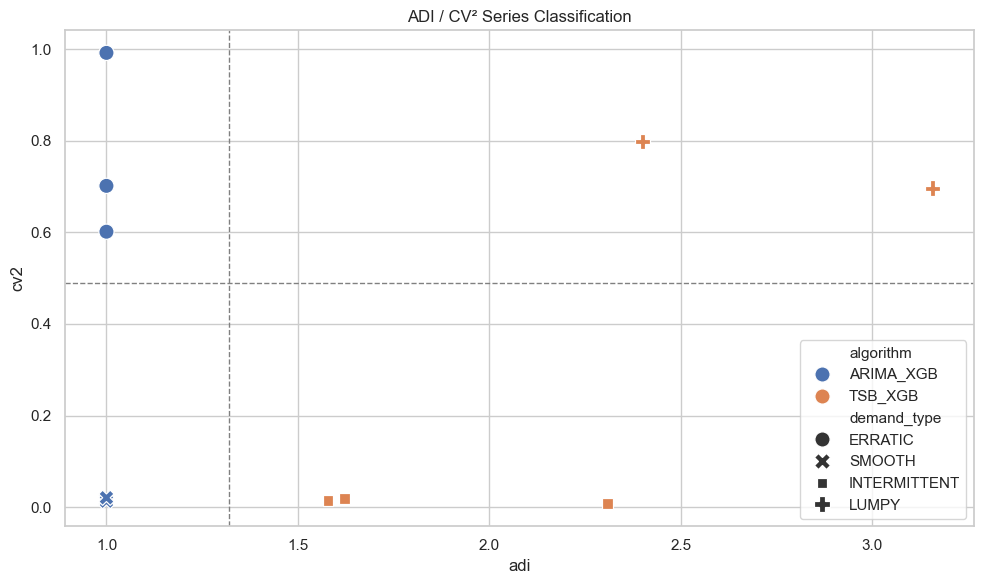

In [5]:
classification_rows = []

for product_name, product_frame in monthly_sales.groupby(PRODUCT_COLUMN, sort=True):
    product_frame = product_frame.sort_values("period").reset_index(drop=True)
    quantities = product_frame[QUANTITY_COLUMN].astype(float).tolist()
    result = classify(quantities)
    classification_rows.append({
        "series_kind": "product",
        "product_name": product_name,
        "observations": len(product_frame),
        "total_quantity": float(product_frame[QUANTITY_COLUMN].sum()),
        "recommended_walk_forward_epochs": recommended_walk_forward_epochs(len(product_frame), min_train_size=MIN_TRAIN_SIZE, max_walk_forward_epochs=MAX_WALK_FORWARD_EPOCHS),
        "adi": result["adi"],
        "cv2": result["cv2"],
        "demand_type": result["demandType"],
        "algorithm": result["algorithm"],
    })

if business_revenue_series is not None and not business_revenue_series.empty:
    revenue_values = business_revenue_series[QUANTITY_COLUMN].astype(float).tolist()
    revenue_result = classify(revenue_values)
    classification_rows.append({
        "series_kind": "business_revenue",
        "product_name": BUSINESS_REVENUE_NAME,
        "observations": len(business_revenue_series),
        "total_quantity": float(business_revenue_series[QUANTITY_COLUMN].sum()),
        "recommended_walk_forward_epochs": recommended_walk_forward_epochs(len(business_revenue_series), min_train_size=MIN_TRAIN_SIZE, max_walk_forward_epochs=MAX_WALK_FORWARD_EPOCHS),
        "adi": revenue_result["adi"],
        "cv2": revenue_result["cv2"],
        "demand_type": revenue_result["demandType"],
        "algorithm": revenue_result["algorithm"],
    })

classification_df = pd.DataFrame(classification_rows).assign(series_priority=lambda df: (df["series_kind"] != "business_revenue").astype(int)).sort_values(["series_priority", "algorithm", "product_name"]).drop(columns=["series_priority"]).reset_index(drop=True)
display(classification_df)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=classification_df, x="adi", y="cv2", hue="algorithm", style="demand_type", s=120, ax=ax)
ax.axvline(1.32, color="gray", linestyle="--", linewidth=1)
ax.axhline(0.49, color="gray", linestyle="--", linewidth=1)
ax.set_title("ADI / CV² Series Classification")
plt.tight_layout()
plt.show()


## Sequential Training by Classified Model

Each product is routed to the algorithm selected by ADI / CV² classification. Statistical-model walk-forward epochs are determined automatically from the product history length.

In [6]:
trainer_map = {
    "ARIMA_XGB": {
        "train_fn": train_arima_xgb,
        "forecast_fn": forecast_arima_xgb,
        "save_fn": save_arima_xgb_model,
        "subdir": TRAINED_MODELS_DIR / "arima_xgb",
        "canonical_dir": TRAINED_MODELS_DIR / "arima_xgb",
        "xgb_initial_rounds": ARIMA_XGB_PARAMS_INITIAL["n_estimators"],
        "xgb_retrain_rounds": ARIMA_XGB_PARAMS_RETRAIN["n_estimators"],
    },
    "TSB_XGB": {
        "train_fn": train_tsb_xgb,
        "forecast_fn": forecast_tsb_xgb,
        "save_fn": save_tsb_xgb_model,
        "subdir": TRAINED_MODELS_DIR / "tsb_xgb",
        "canonical_dir": TRAINED_MODELS_DIR / "tsb_xgb",
        "xgb_initial_rounds": TSB_XGB_PARAMS_INITIAL["n_estimators"],
        "xgb_retrain_rounds": TSB_XGB_PARAMS_RETRAIN["n_estimators"],
    },
}

training_summaries = []
epoch_results = {}
forecast_results = {}
skipped_products = []

for row in classification_df.to_dict(orient="records"):
    product_name = row["product_name"]
    algorithm = row["algorithm"]
    series_kind = row.get("series_kind", "product")

    if series_kind == "business_revenue":
        product_history = business_revenue_series.sort_values("period").reset_index(drop=True).copy()
    else:
        product_history = monthly_sales[monthly_sales[PRODUCT_COLUMN] == product_name].sort_values("period").reset_index(drop=True).copy()

    dates = product_history["period_str"].tolist()
    quantities = product_history[QUANTITY_COLUMN].astype(float).tolist()
    walk_forward_epochs = recommended_walk_forward_epochs(len(dates), min_train_size=MIN_TRAIN_SIZE, max_walk_forward_epochs=MAX_WALK_FORWARD_EPOCHS)

    if len(dates) <= MIN_TRAIN_SIZE:
        skipped_products.append({
            "product_name": product_name,
            "algorithm": algorithm,
            "reason": f"Need more than {MIN_TRAIN_SIZE} monthly observations",
            "observations": len(dates),
        })
        continue

    config = trainer_map[algorithm]
    config["subdir"].mkdir(parents=True, exist_ok=True)

    if series_kind == "business_revenue":
        config["canonical_dir"].mkdir(parents=True, exist_ok=True)
        output_path = config["canonical_dir"] / f"{BUSINESS_REVENUE_ARTIFACT_NAME}.pkl"
    else:
        output_path = config["subdir"] / f"{slugify_name(product_name)}.pkl"

    epoch_frame = run_sequential_epochs(
        dates=dates,
        quantities=quantities,
        train_fn=config["train_fn"],
        forecast_fn=config["forecast_fn"],
        min_train_size=MIN_TRAIN_SIZE,
        test_size=walk_forward_epochs,
    )

    artifact, forecast_rows, final_meta, _ = config["train_fn"](dates, quantities, horizon=FORECAST_HORIZON)
    saved_model_path = config["save_fn"](artifact, output_path)

    epoch_results[product_name] = epoch_frame
    forecast_results[product_name] = pd.DataFrame(forecast_rows)

    summary = summarize_epochs(
        epoch_frame=epoch_frame,
        product_name=product_name,
        model_name=algorithm,
        demand_type=row["demand_type"],
        adi=row["adi"],
        cv2=row["cv2"],
        saved_model_path=saved_model_path,
        walk_forward_epochs=walk_forward_epochs,
        xgb_rounds_initial=config["xgb_initial_rounds"],
        xgb_rounds_retrain=config["xgb_retrain_rounds"],
    )
    summary.update({"series_kind": series_kind})
    summary.update(final_meta)
    training_summaries.append(summary)

training_summary_df = pd.DataFrame(training_summaries).assign(series_priority=lambda df: (df["series_kind"] != "business_revenue").astype(int)).sort_values(["series_priority", "algorithm", "MAPE", "RMSE"]).drop(columns=["series_priority"]).reset_index(drop=True)
skipped_df = pd.DataFrame(skipped_products)

display(Markdown("### Training Summary"))
display(training_summary_df)

if not skipped_df.empty:
    display(Markdown("### Skipped Products"))
    display(skipped_df)


c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Joem Inciong\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Training Summary

,product_name,algorithm,demand_type,adi,cv2,walk_forward_epochs,xgb_rounds_initial,xgb_rounds_retrain,epochs,avg_train_size,saved_model_path,RMSE,MSE,MAE,MAPE,series_kind,arima_order,arima_aic,n_train,horizon,mape,accuracy,xgb_enabled,tsb_alpha,tsb_beta,tsb_mse
0,Business Total Revenue,ARIMA_XGB,ERRATIC,1.0000,0.9917,12,200,400,12,53.5000,C:\Users\Joem Inciong\automotive-spare-parts-d...,"5,654,087.6693","31,968,707,371,601.4688","4,581,237.8683",182.1458,business_revenue,"[0, 1, 1]","1,977.3489",60,6,52.7200,47.2800,True,NaN,NaN,NaN
1,Brake Pads,ARIMA_XGB,SMOOTH,1.0000,0.0130,12,200,400,12,53.5000,C:\Users\Joem Inciong\automotive-spare-parts-d...,15.0385,226.1567,11.6808,8.1730,product,"[0, 1, 1]",499.0989,60,6,3.6000,96.4000,True,NaN,NaN,NaN
2,Air Filter,ARIMA_XGB,SMOOTH,1.0000,0.0170,12,200,400,12,53.5000,C:\Users\Joem Inciong\automotive-spare-parts-d...,14.9300,222.9047,11.3250,11.9292,product,"[0, 1, 1]",476.9896,60,6,5.0500,94.9500,True,NaN,NaN,NaN
3,Oil Filter,ARIMA_XGB,SMOOTH,1.0000,0.0205,12,200,400,12,53.5000,C:\Users\Joem Inciong\automotive-spare-parts-d...,20.1918,407.7108,17.5283,13.3685,product,"[0, 1, 1]",529.0147,60,6,3.7700,96.2300,True,NaN,NaN,NaN
4,Wheel Bearing,ARIMA_XGB,ERRATIC,1.0000,0.7014,12,200,400,12,53.5000,C:\Users\Joem Inciong\automotive-spare-parts-d...,57.3794,"3,292.3954",37.2817,155.8869,product,"[0, 1, 1]",669.8087,60,6,32.2900,67.7100,True,NaN,NaN,NaN
5,Shock Absorber,ARIMA_XGB,ERRATIC,1.0000,0.6013,12,200,400,12,53.5000,C:\Users\Joem Inciong\automotive-spare-parts-d...,78.7357,"6,199.3114",67.9158,455.9966,product,"[0, 1, 1]",708.2659,60,6,23.3100,76.6900,True,NaN,NaN,NaN
6,Starter Motor,TSB_XGB,INTERMITTENT,1.5789,0.0142,12,200,400,12,53.5000,C:\Users\Joem Inciong\automotive-spare-parts-d...,30.8402,951.1189,27.0492,41.8779,product,NaN,NaN,60,6,5.2400,94.7600,True,0.5000,0.5000,210.6564
7,Alternator,TSB_XGB,INTERMITTENT,1.6216,0.0192,12,200,400,12,53.5000,C:\Users\Joem Inciong\automotive-spare-parts-d...,43.5891,"1,900.0077",39.5875,43.6153,product,NaN,NaN,60,6,5.0500,94.9500,True,0.5000,0.5000,481.4525
8,Battery,TSB_XGB,INTERMITTENT,2.3077,0.0075,12,200,400,12,53.5000,C:\Users\Joem Inciong\automotive-spare-parts-d...,31.8587,"1,014.9743",25.0358,46.2306,product,NaN,NaN,60,6,4.0500,95.9500,True,0.5000,0.5000,342.3161
9,Catalytic Converter,TSB_XGB,LUMPY,2.4000,0.7975,12,200,400,12,53.5000,C:\Users\Joem Inciong\automotive-spare-parts-d...,95.9294,"9,202.4538",72.5900,66.0125,product,NaN,NaN,60,6,113.9800,-13.9800,True,0.5000,0.5000,"3,472.6334"


## Metrics by Model Type

,algorithm,RMSE,MSE,MAE,MAPE
0,ARIMA_XGB,"942,378.9908","5,328,117,896,991.6582","763,563.9333",137.9167
1,TSB_XGB,77.9665,"9,653.5916",56.7143,161.1181


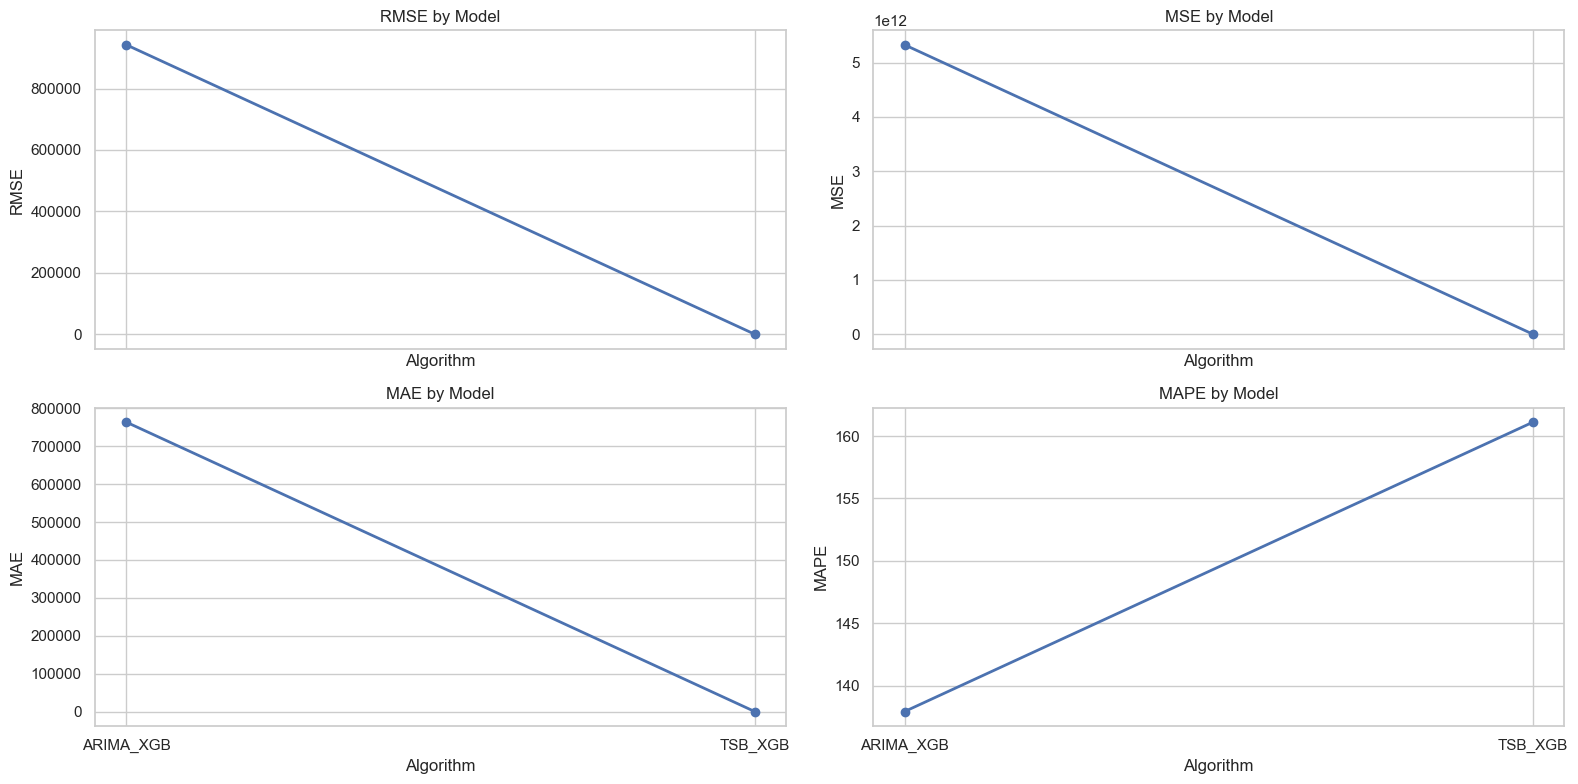

In [7]:
model_metric_summary = (
    training_summary_df.groupby("algorithm", as_index=False)[["RMSE", "MSE", "MAE", "MAPE"]]
    .mean()
    .sort_values("MAPE")
)

display(model_metric_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
for axis, metric_name in zip(axes.flatten(), METRIC_COLUMNS):
    axis.plot(model_metric_summary["algorithm"], model_metric_summary[metric_name], marker="o", linewidth=2)
    axis.set_title(f"{metric_name} by Model")
    axis.set_xlabel("Algorithm")
    axis.set_ylabel(metric_name)
plt.tight_layout()
plt.show()

## Spare Part Performance Metrics

,product_name,algorithm,demand_type,RMSE,MSE,MAE,MAPE
0,Brake Pads,ARIMA_XGB,SMOOTH,15.0385,226.1567,11.6808,8.1730
1,Air Filter,ARIMA_XGB,SMOOTH,14.9300,222.9047,11.3250,11.9292
2,Oil Filter,ARIMA_XGB,SMOOTH,20.1918,407.7108,17.5283,13.3685
3,Wheel Bearing,ARIMA_XGB,ERRATIC,57.3794,"3,292.3954",37.2817,155.8869
4,Shock Absorber,ARIMA_XGB,ERRATIC,78.7357,"6,199.3114",67.9158,455.9966
5,Starter Motor,TSB_XGB,INTERMITTENT,30.8402,951.1189,27.0492,41.8779
6,Alternator,TSB_XGB,INTERMITTENT,43.5891,"1,900.0077",39.5875,43.6153
7,Battery,TSB_XGB,INTERMITTENT,31.8587,"1,014.9743",25.0358,46.2306
8,Catalytic Converter,TSB_XGB,LUMPY,95.9294,"9,202.4538",72.5900,66.0125
9,ECU Module,TSB_XGB,LUMPY,187.6150,"35,199.4030",119.3092,607.8543


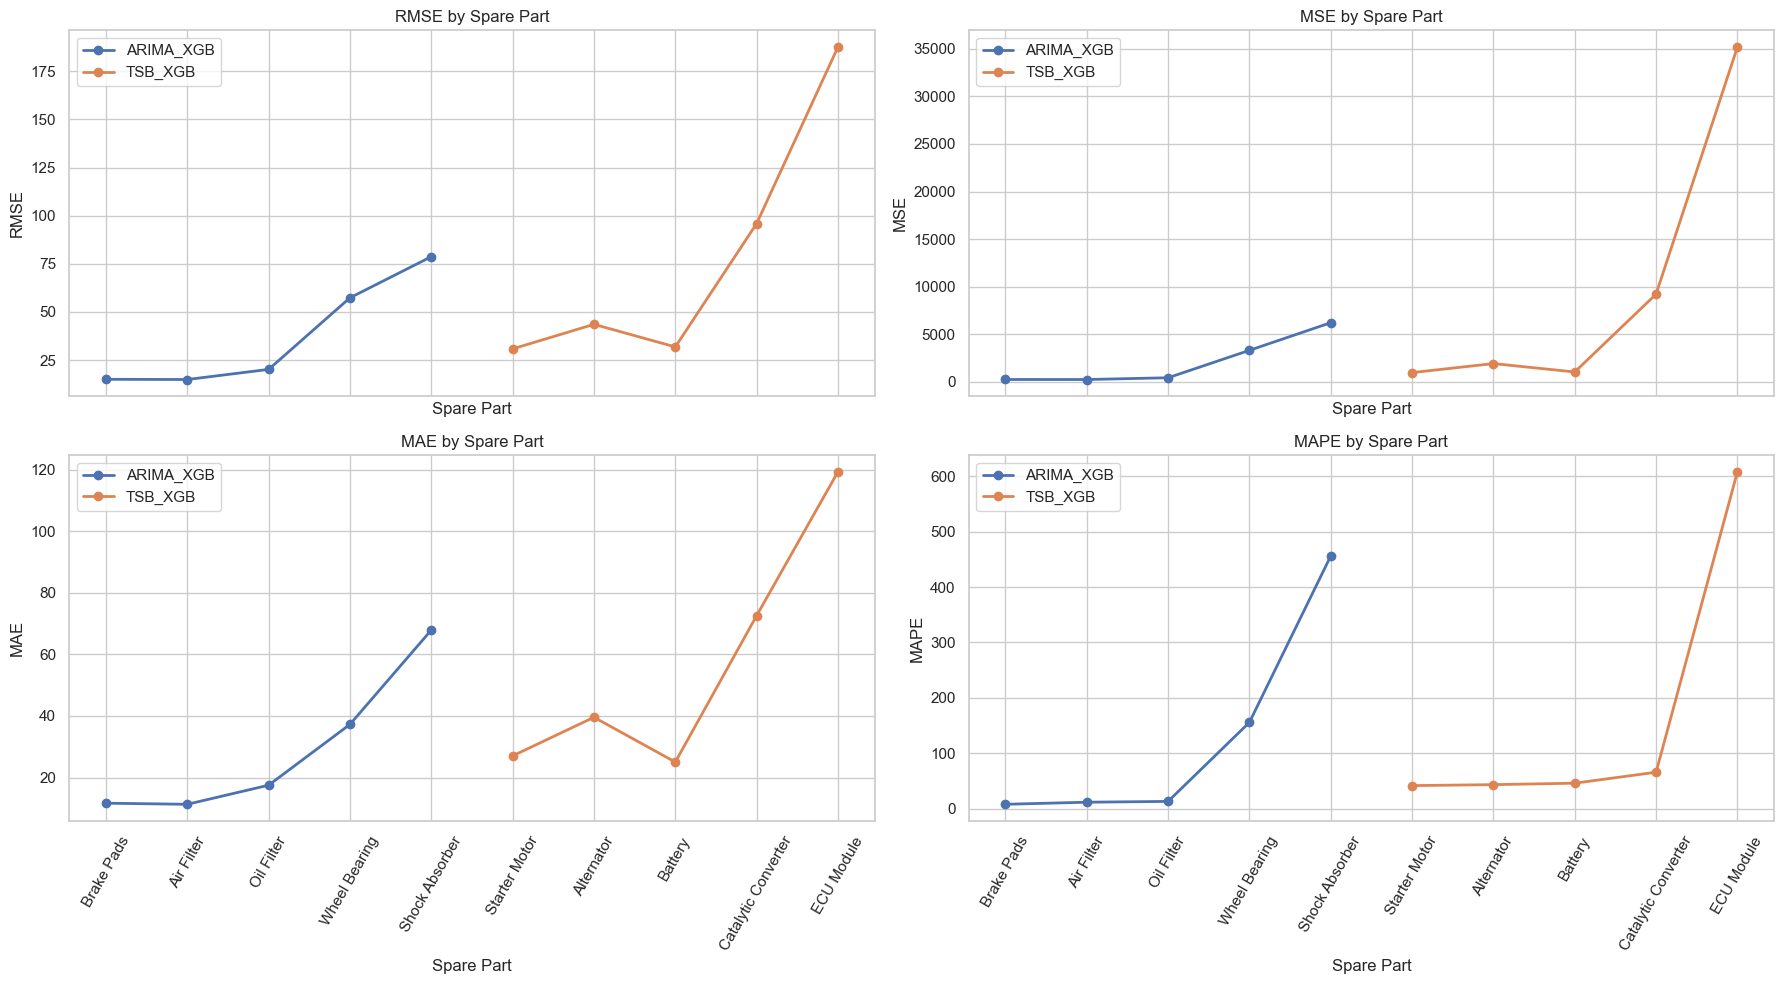

In [8]:
spare_part_metric_summary = (
    training_summary_df[training_summary_df["series_kind"] != "business_revenue"]
    [["product_name", "algorithm", "demand_type", *METRIC_COLUMNS]]
    .sort_values(["algorithm", "MAPE", "RMSE", "product_name"])
    .reset_index(drop=True)
)

display(spare_part_metric_summary)

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)
for axis, metric_name in zip(axes.flatten(), METRIC_COLUMNS):
    for algorithm_name, group in spare_part_metric_summary.groupby("algorithm"):
        axis.plot(group["product_name"], group[metric_name], marker="o", linewidth=2, label=algorithm_name)
    axis.set_title(f"{metric_name} by Spare Part")
    axis.set_xlabel("Spare Part")
    axis.set_ylabel(metric_name)
    axis.tick_params(axis="x", rotation=60)
    axis.legend()
plt.tight_layout()
plt.show()

## Spare Part Training Plots

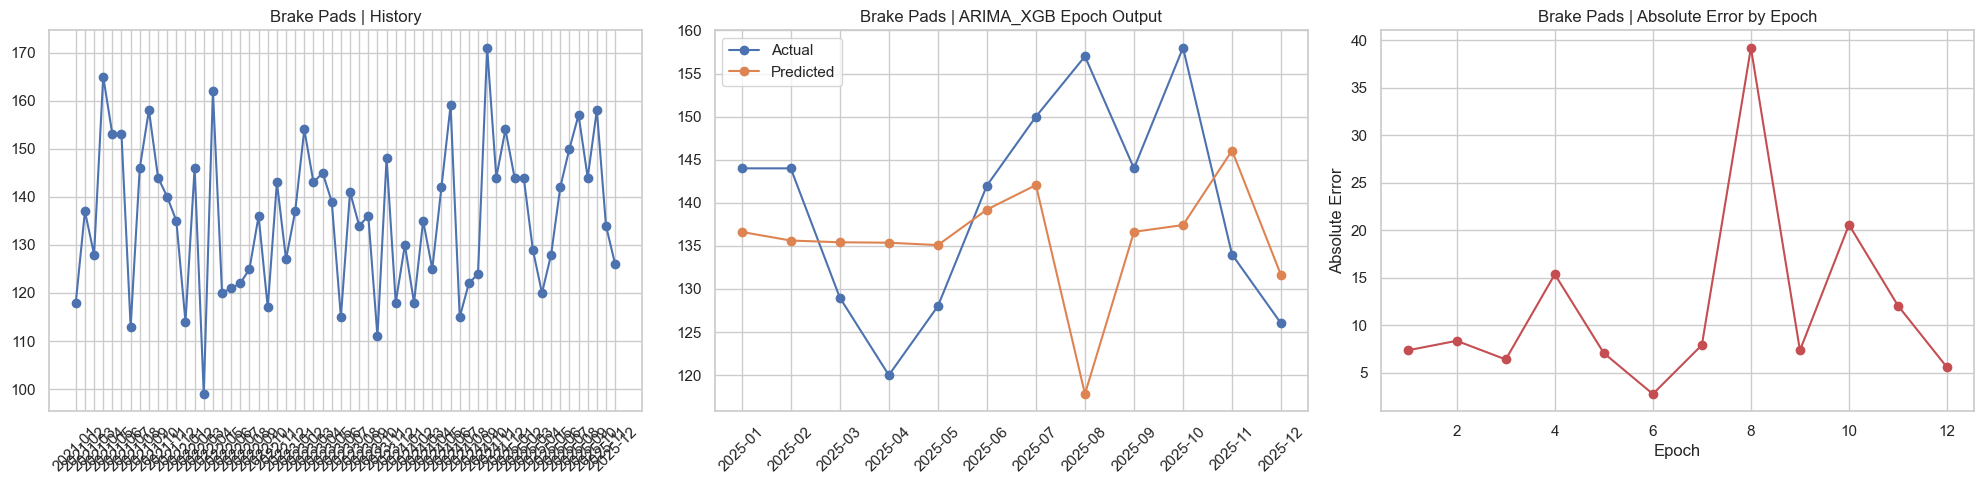

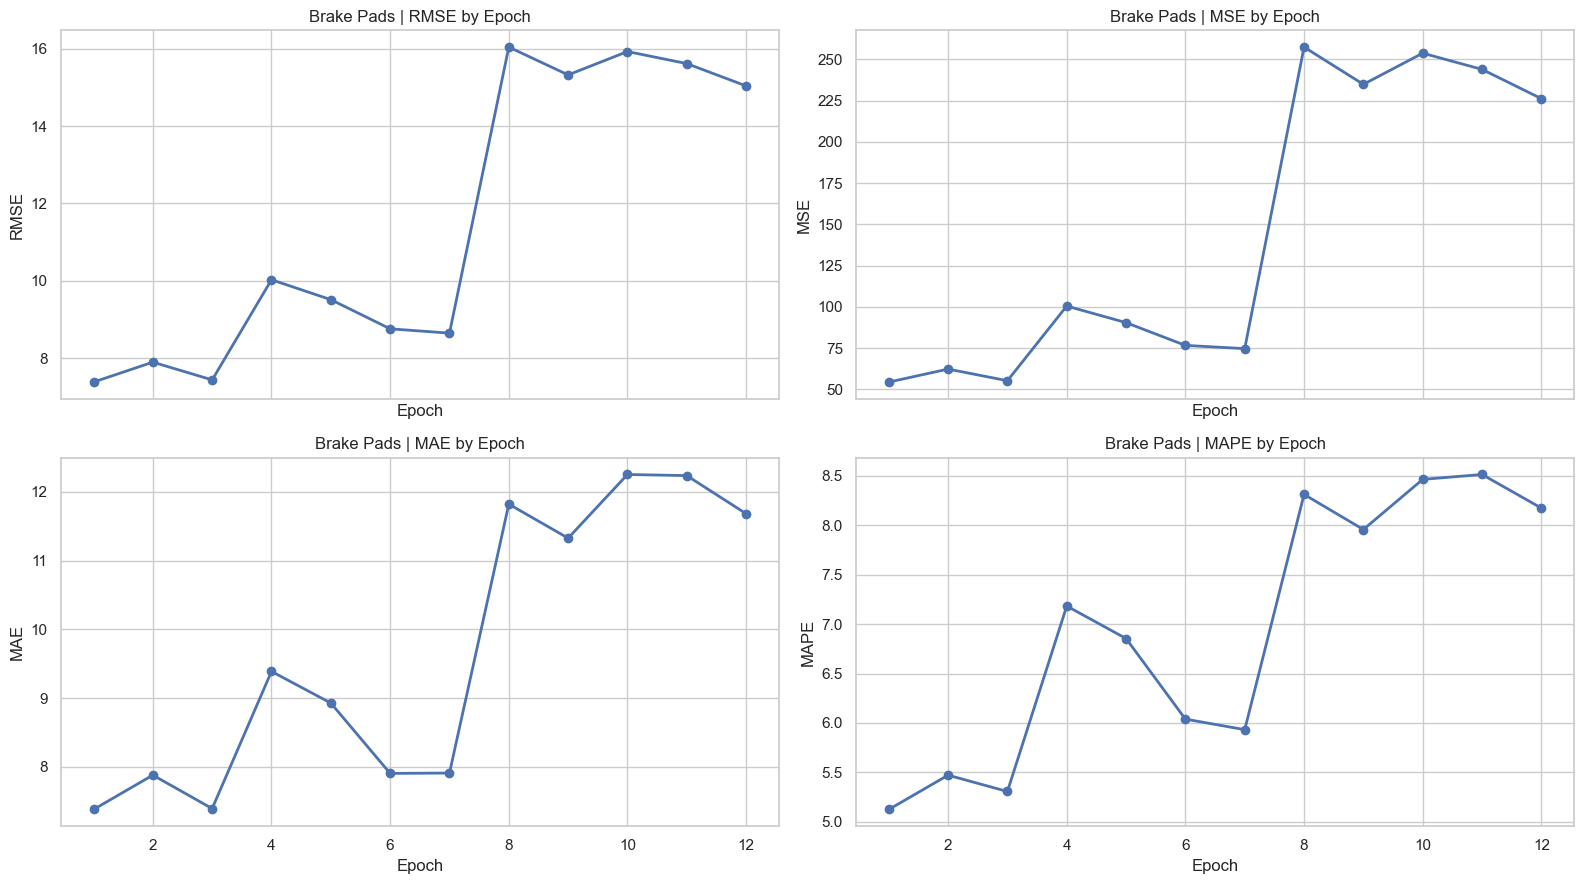

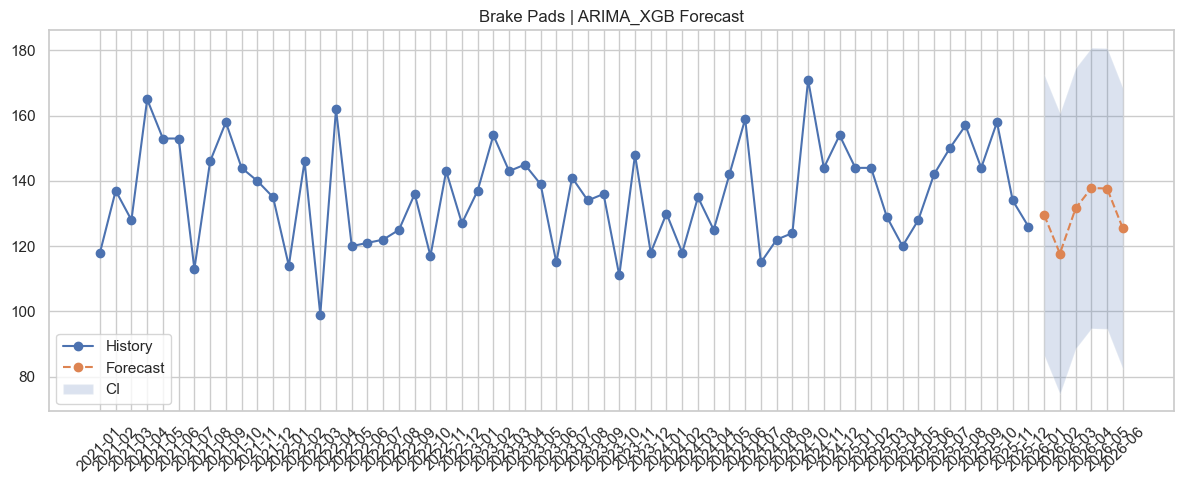

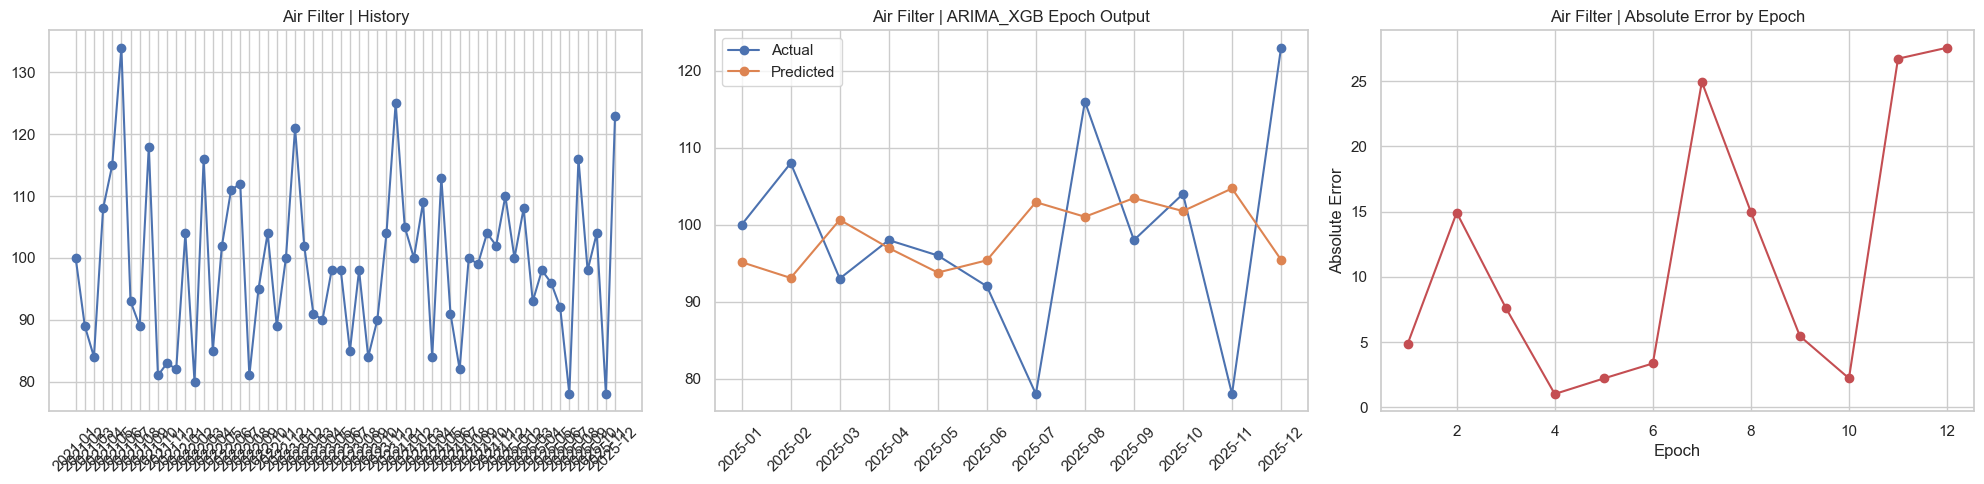

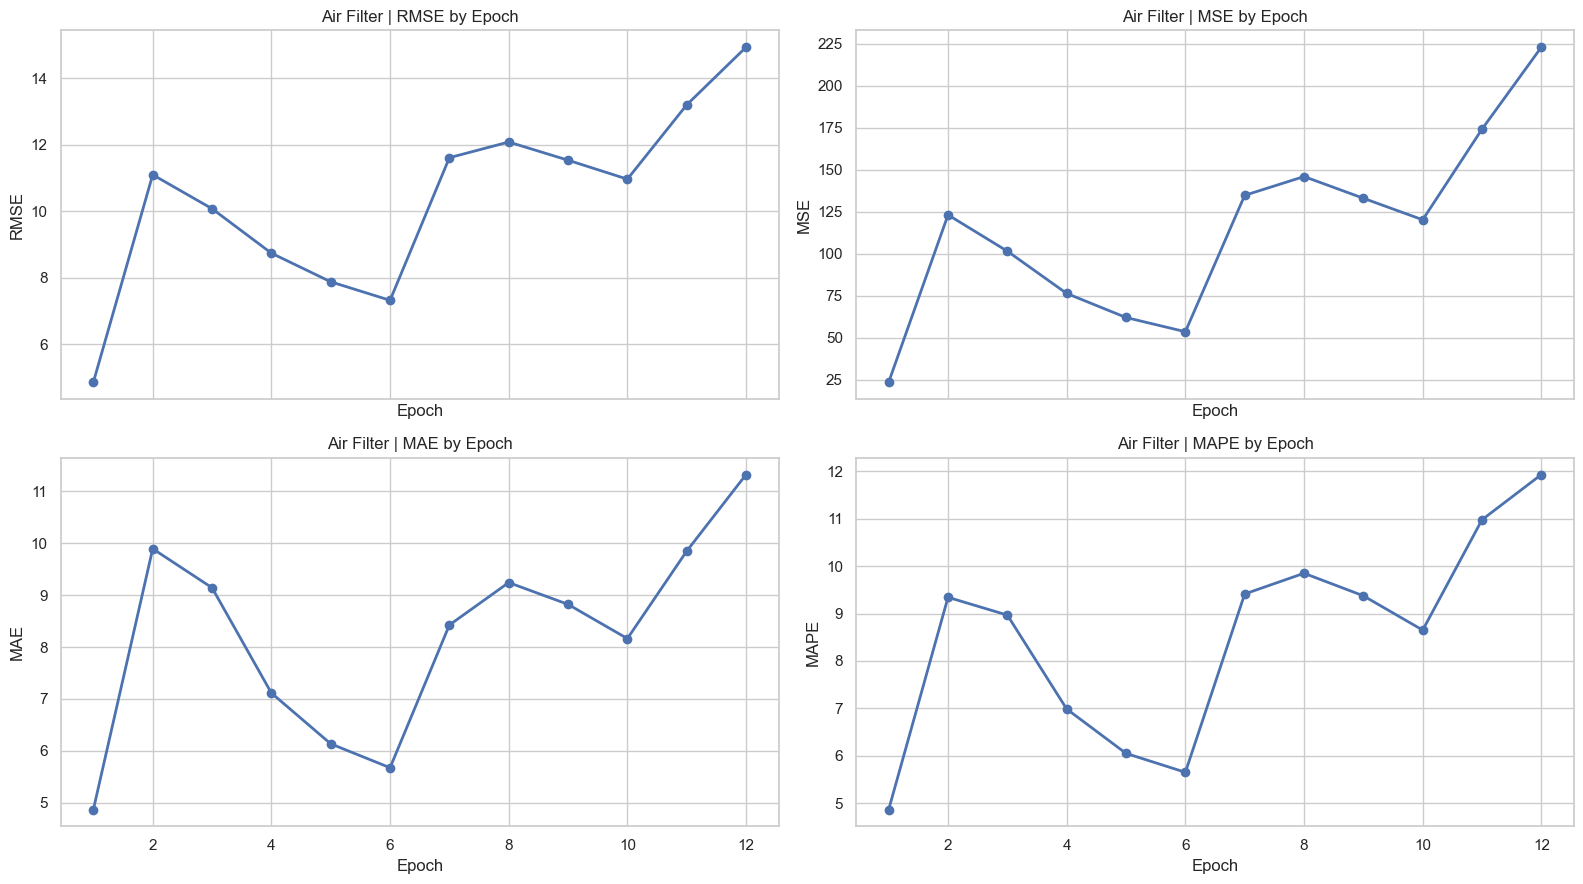

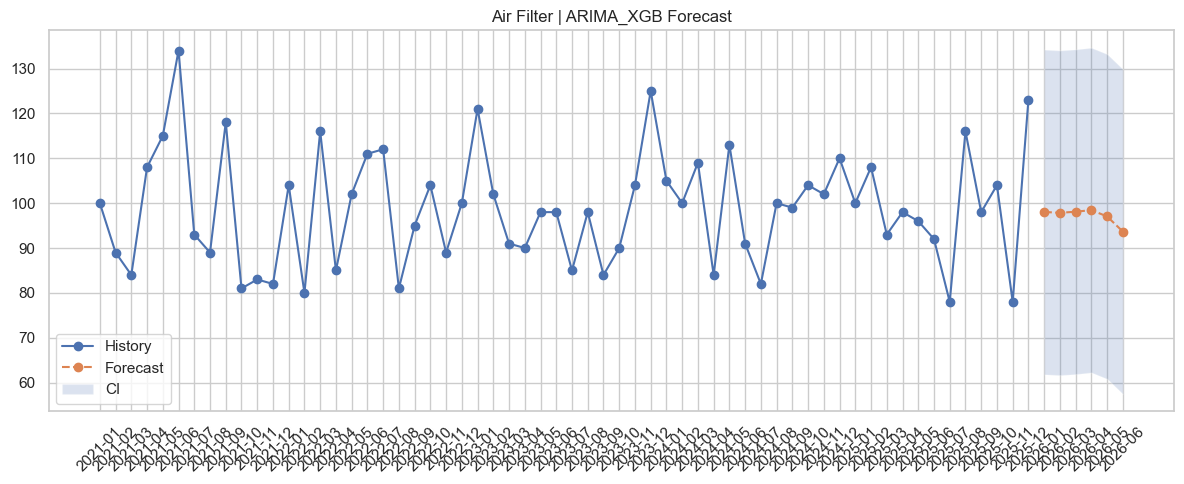

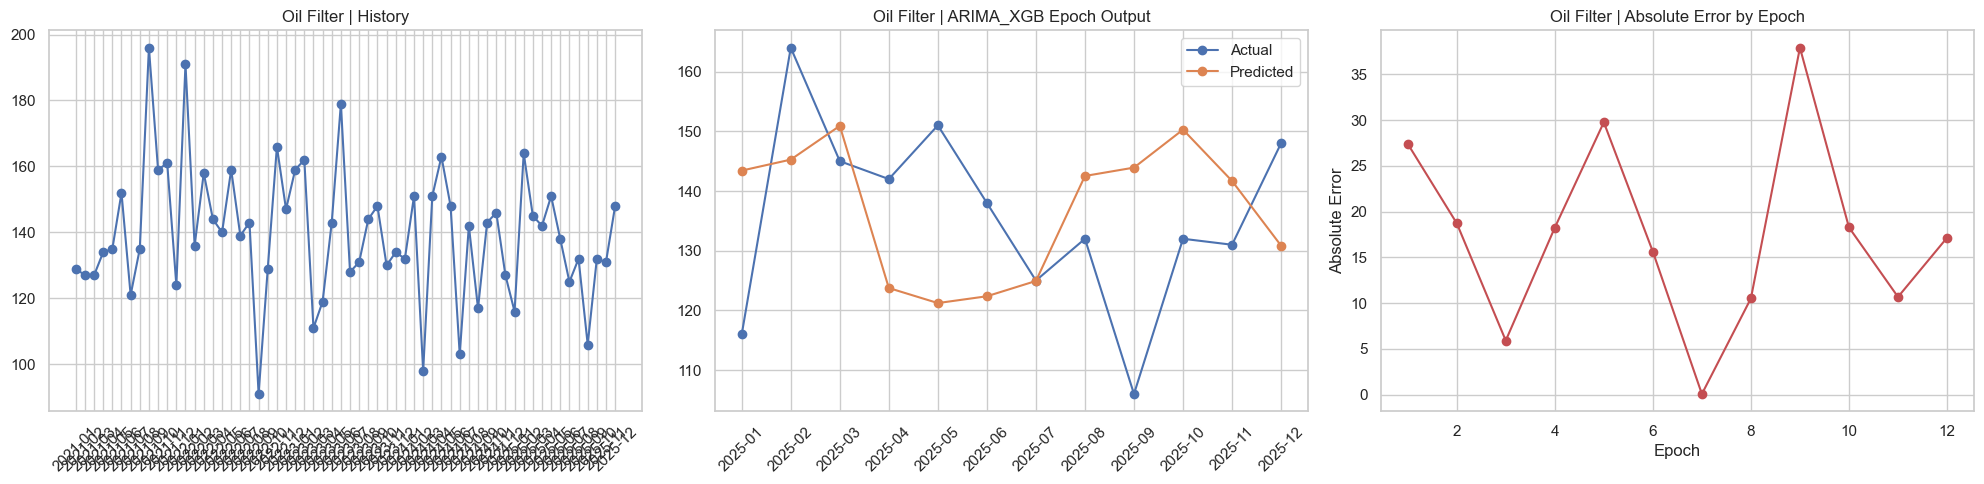

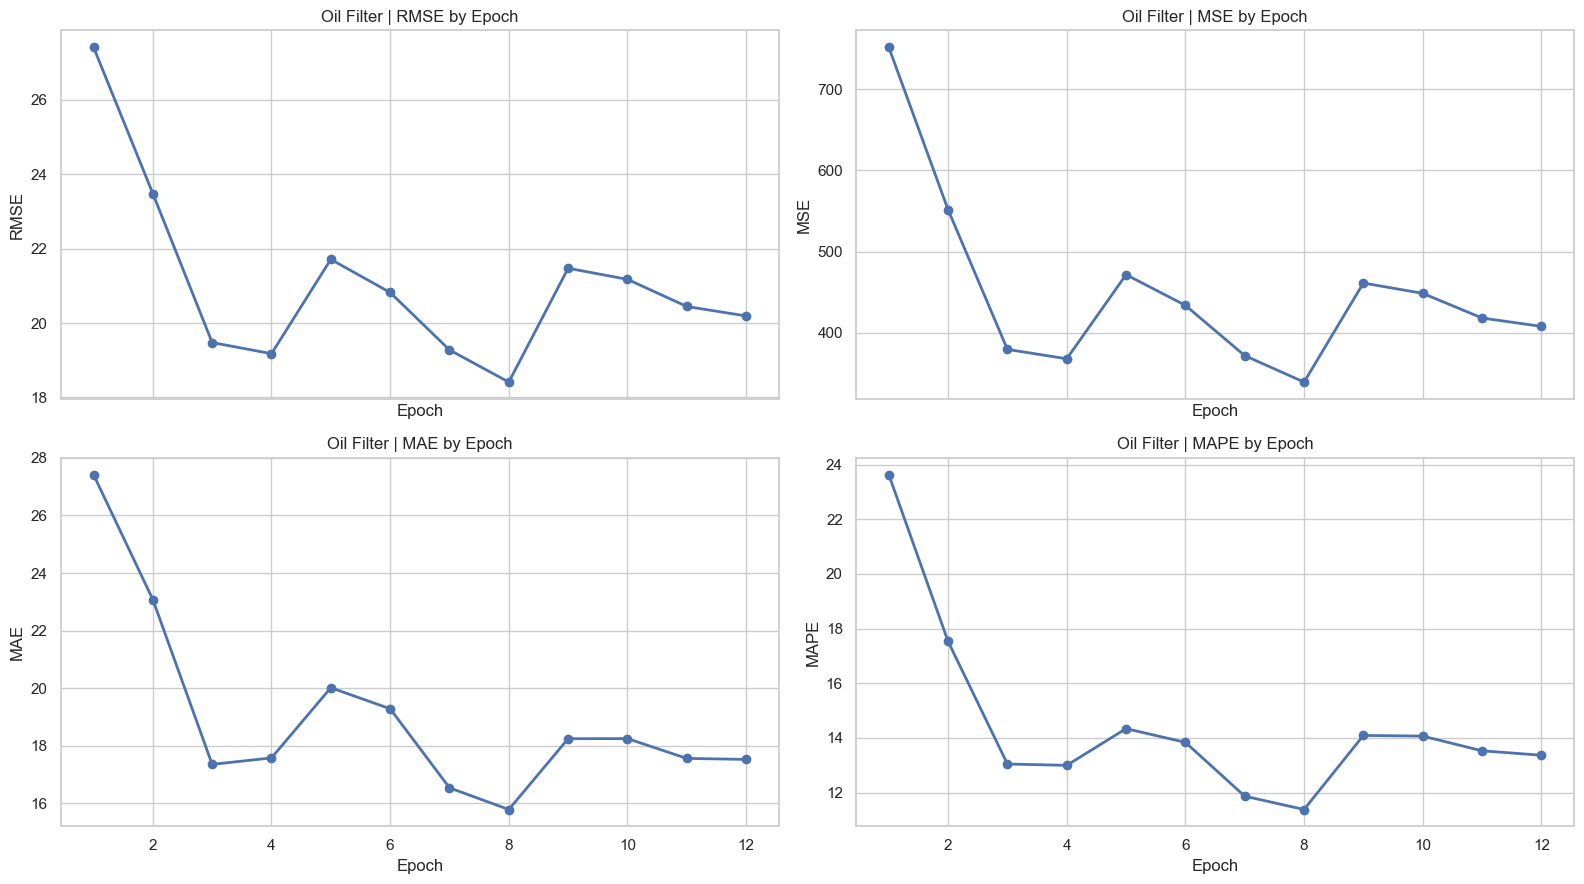

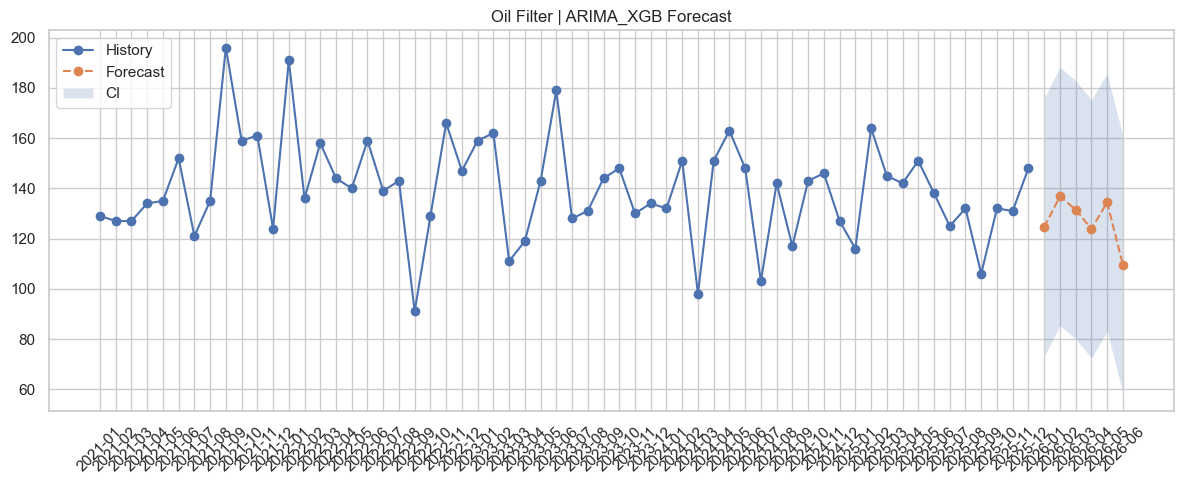

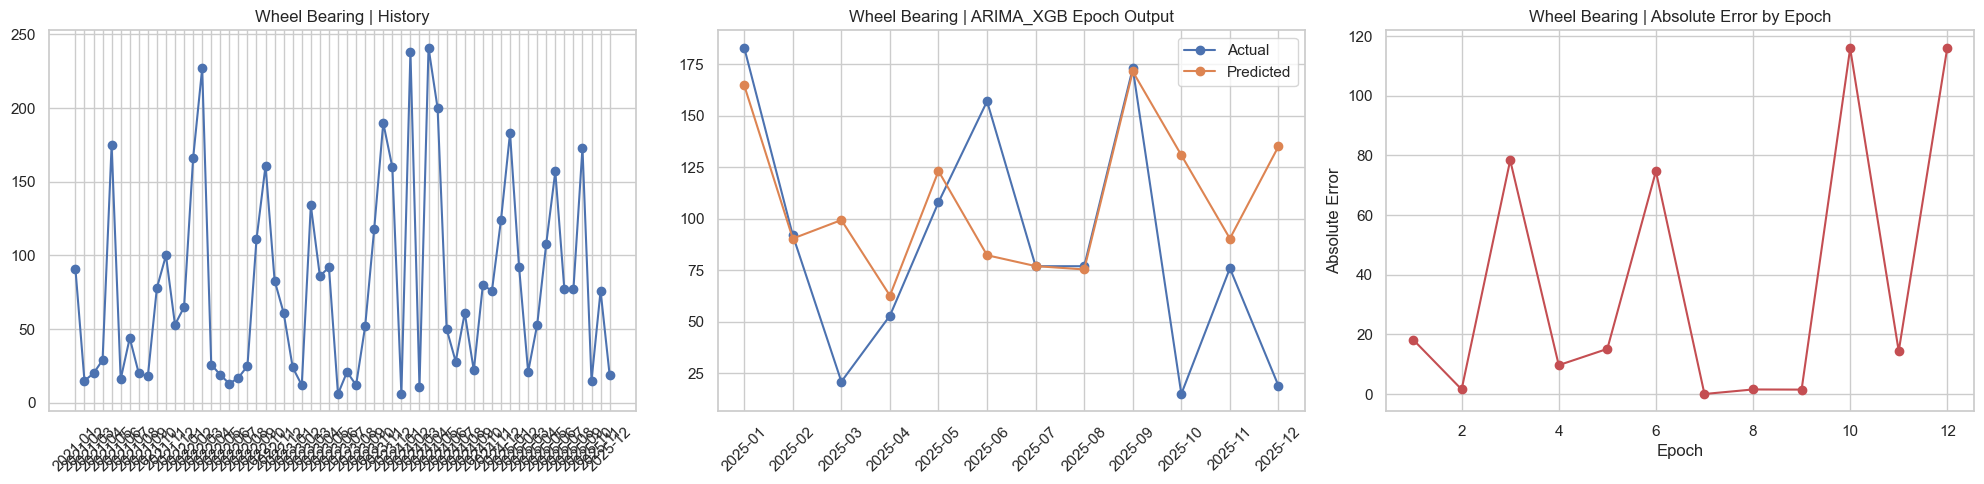

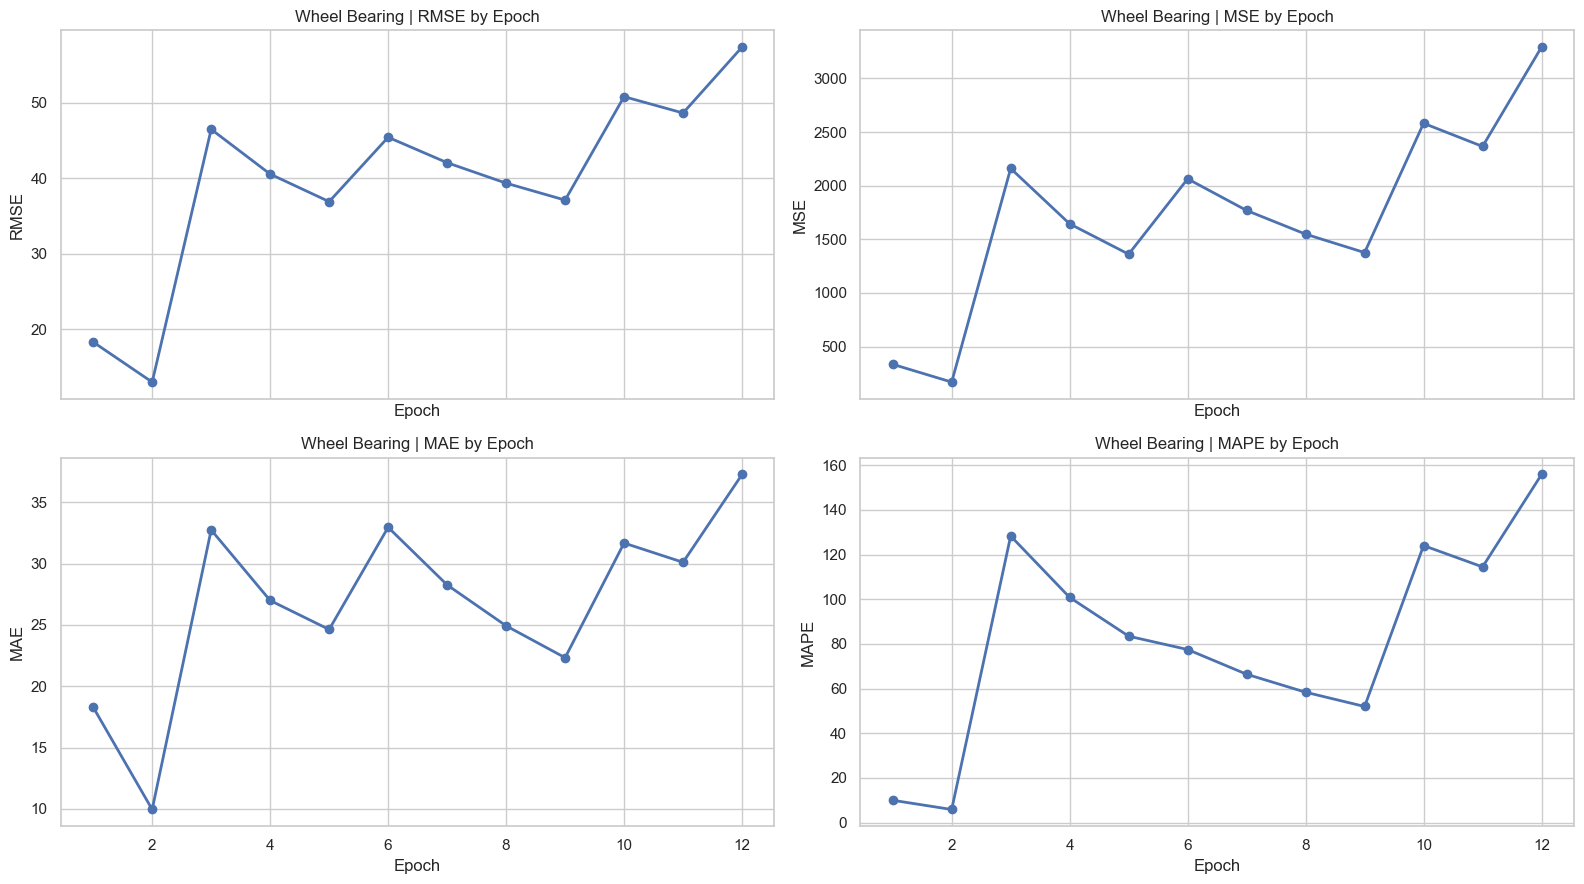

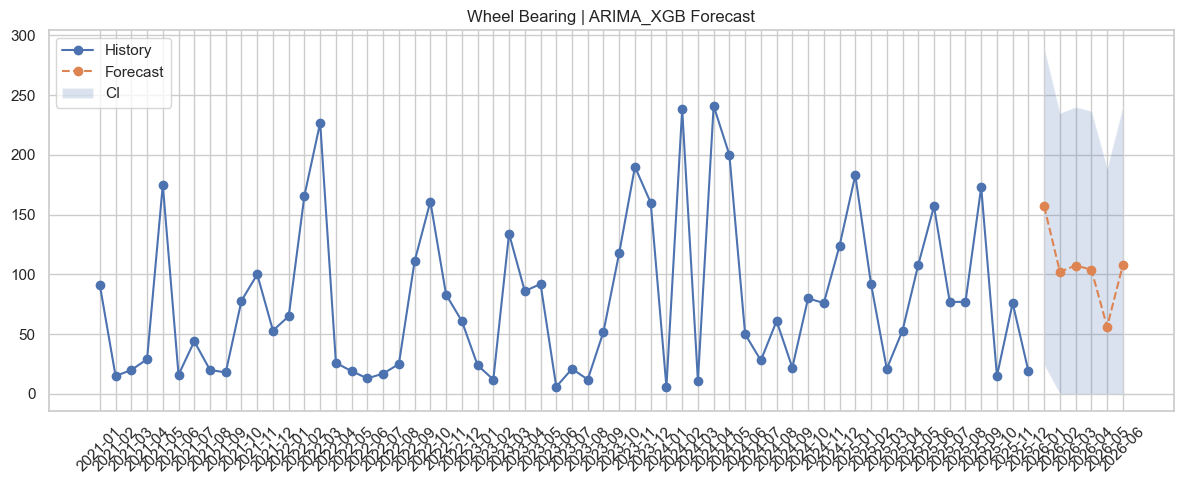

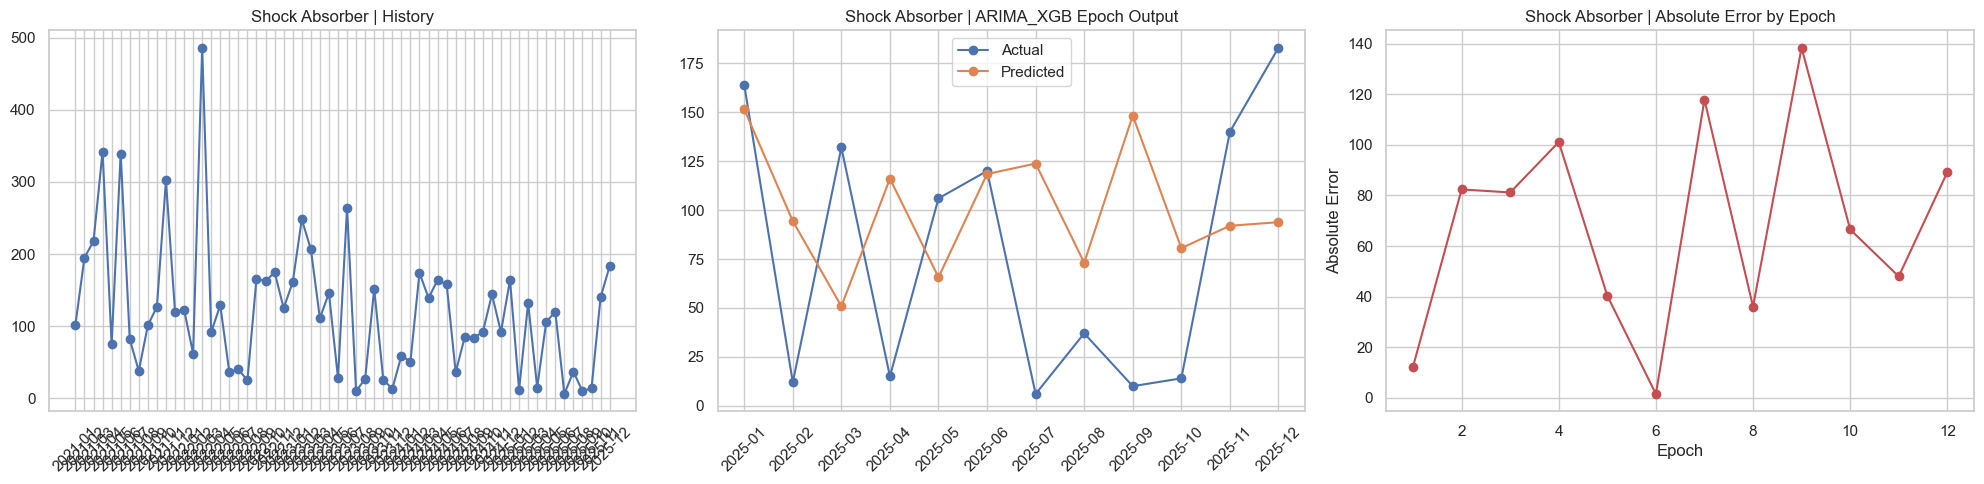

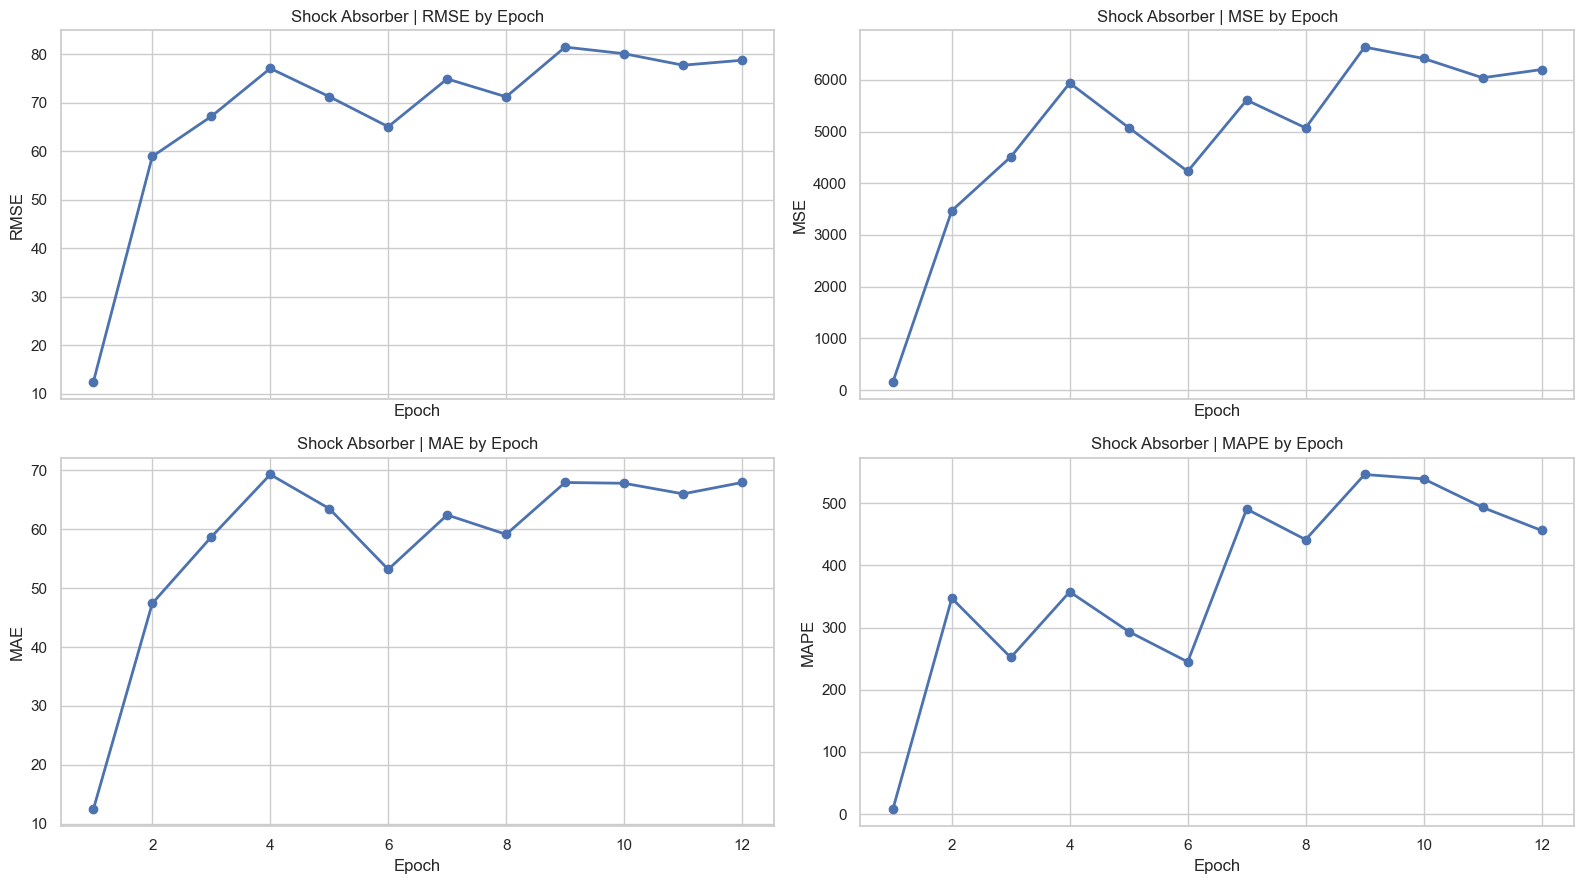

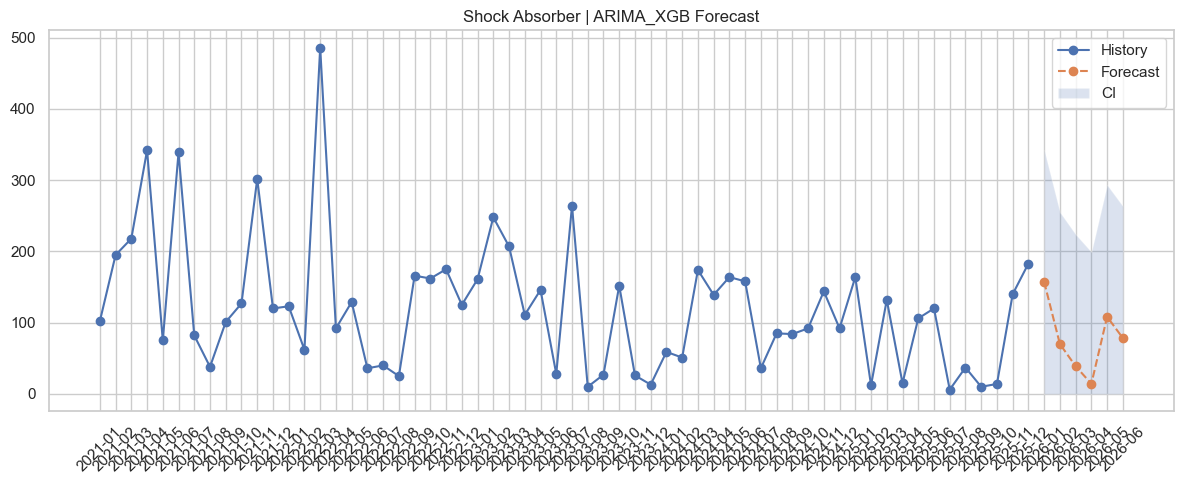

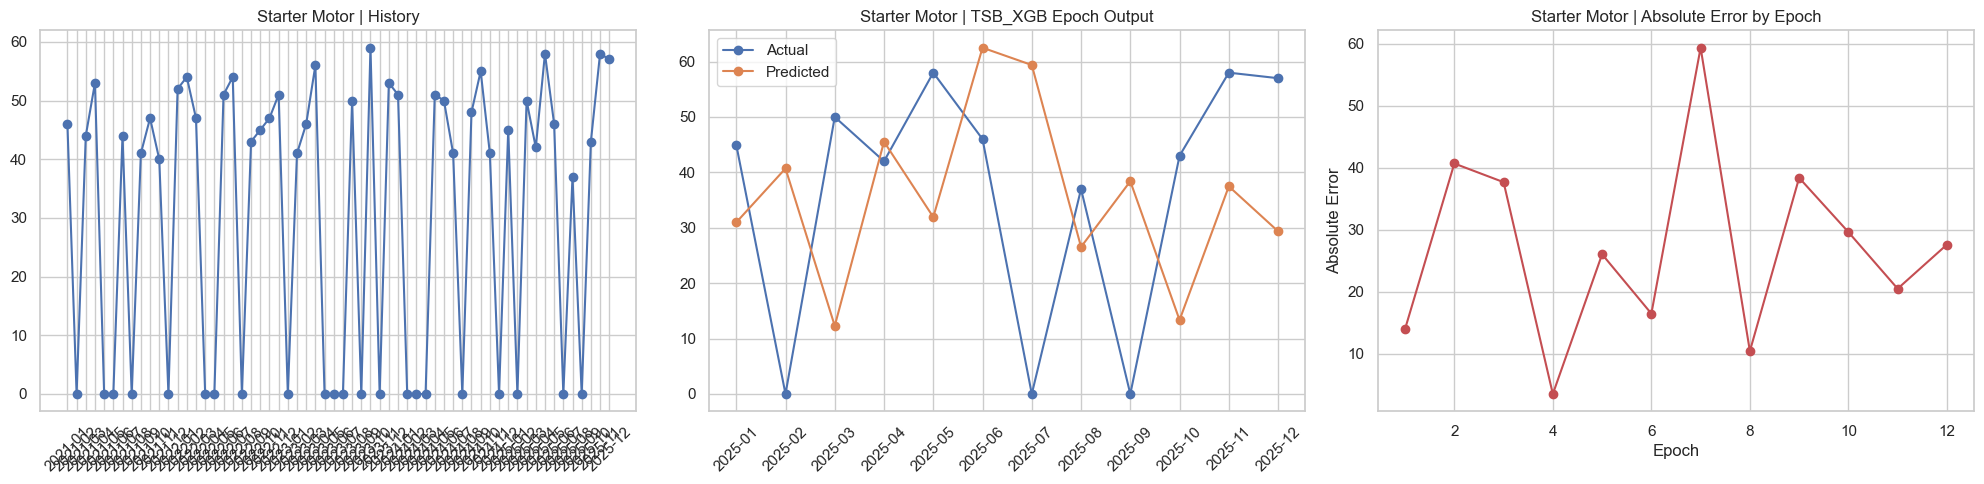

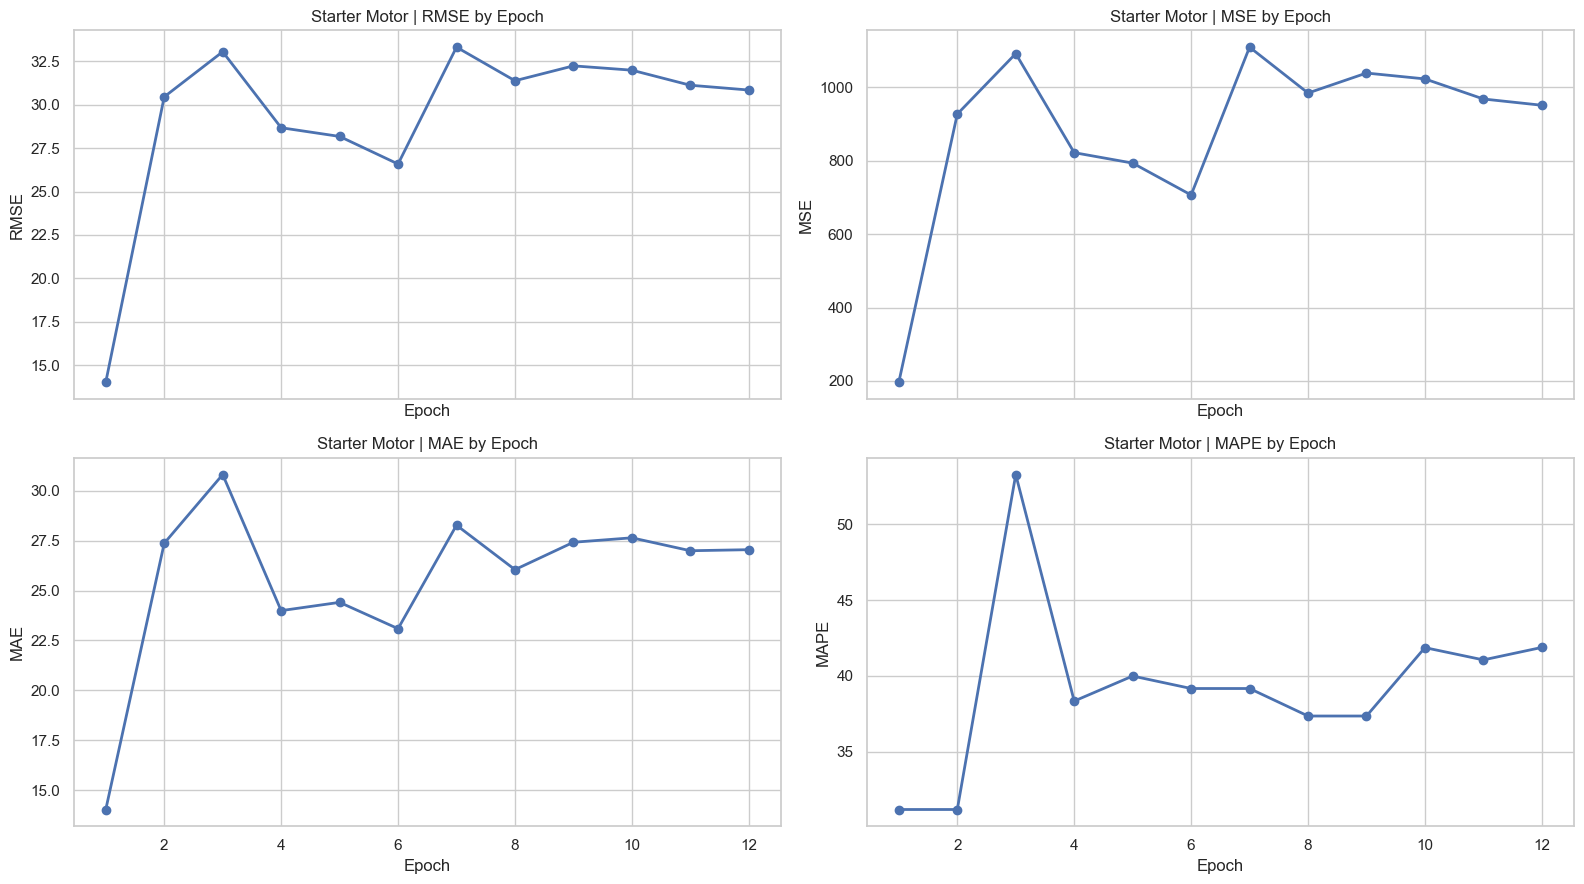

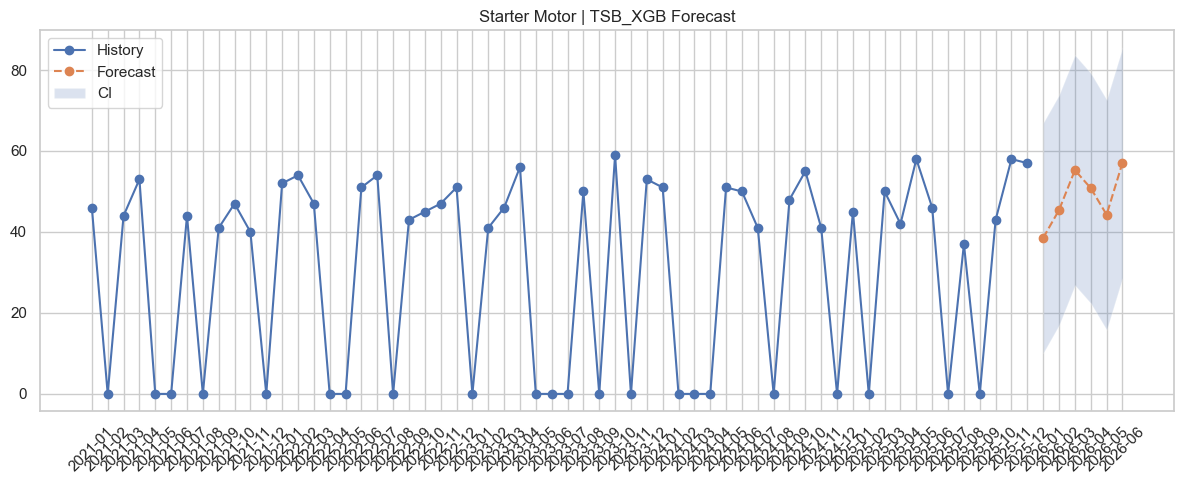

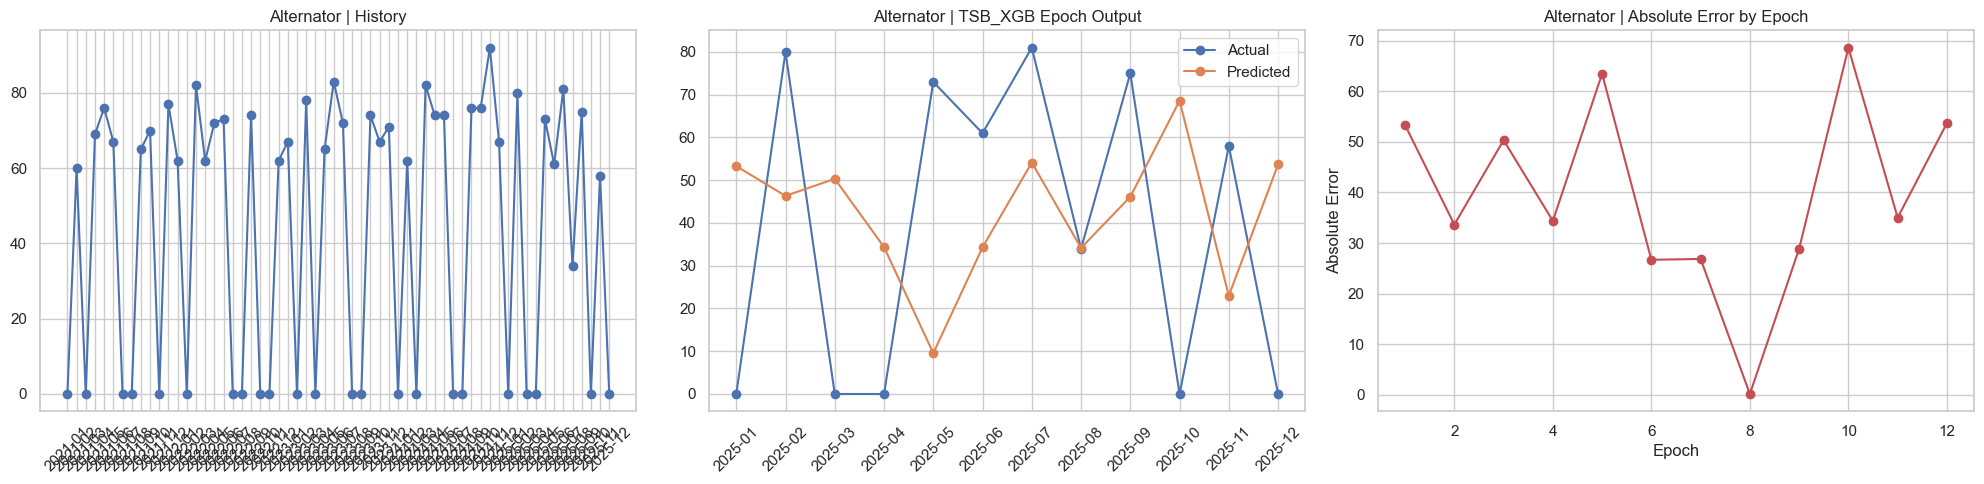

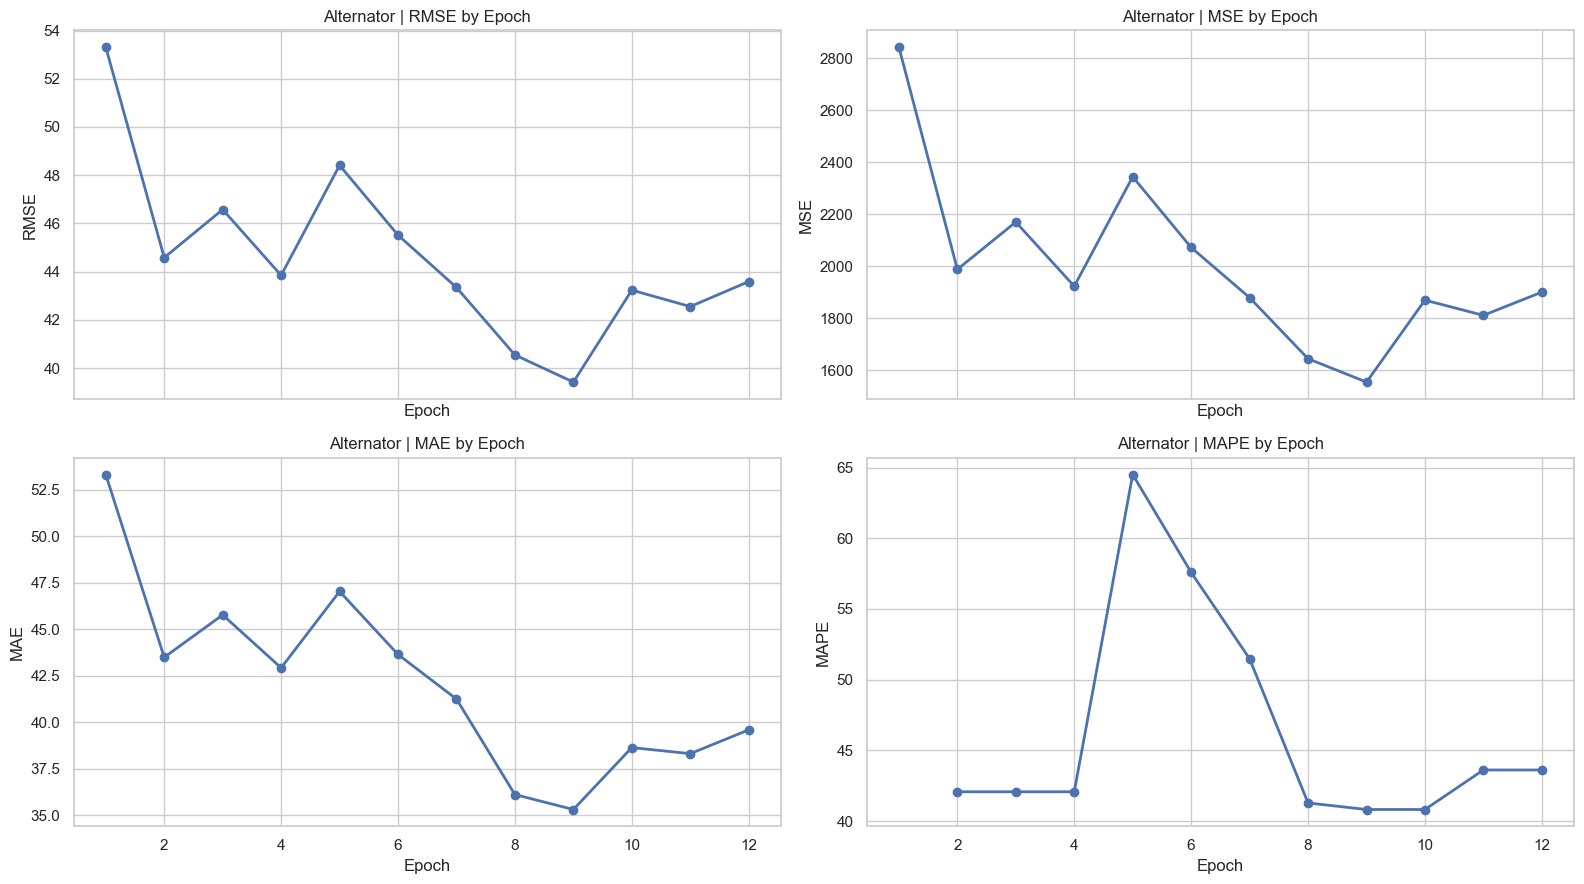

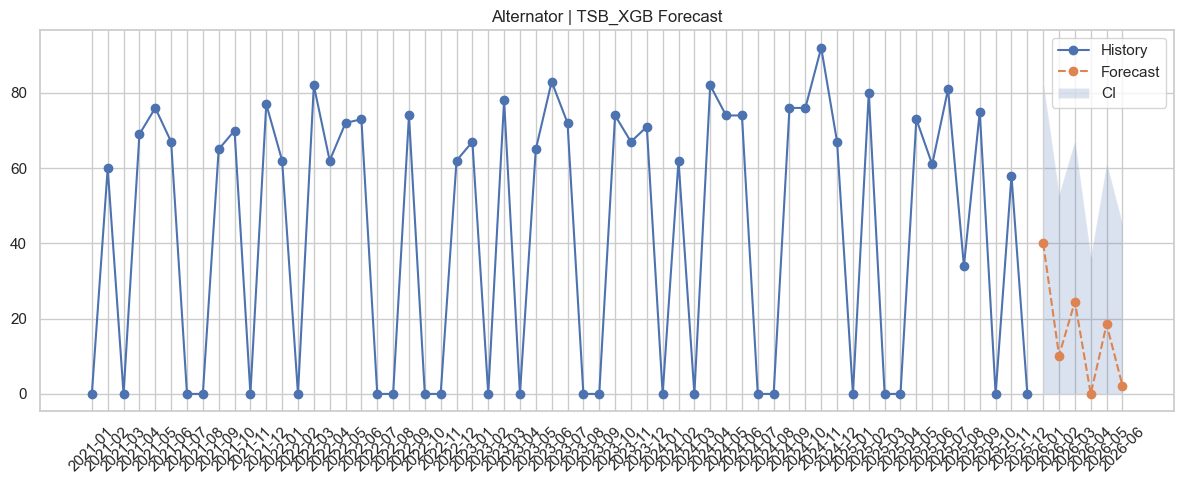

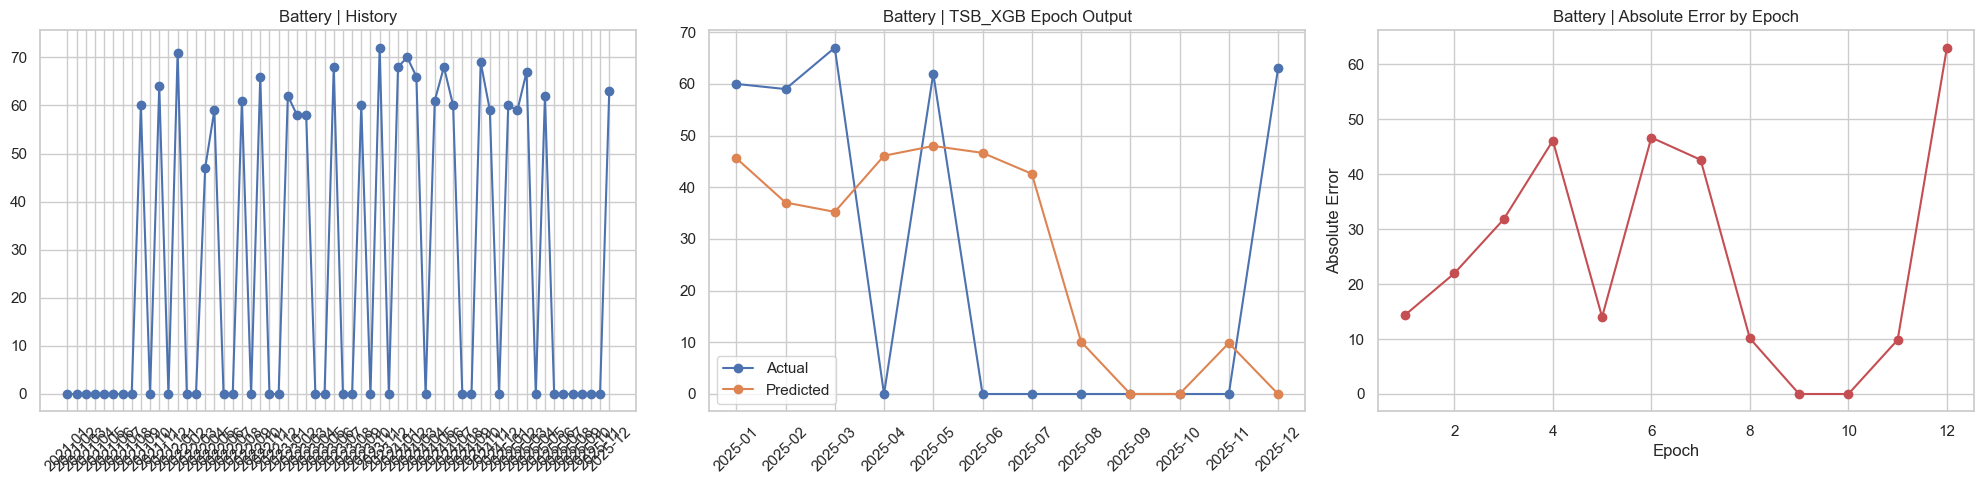

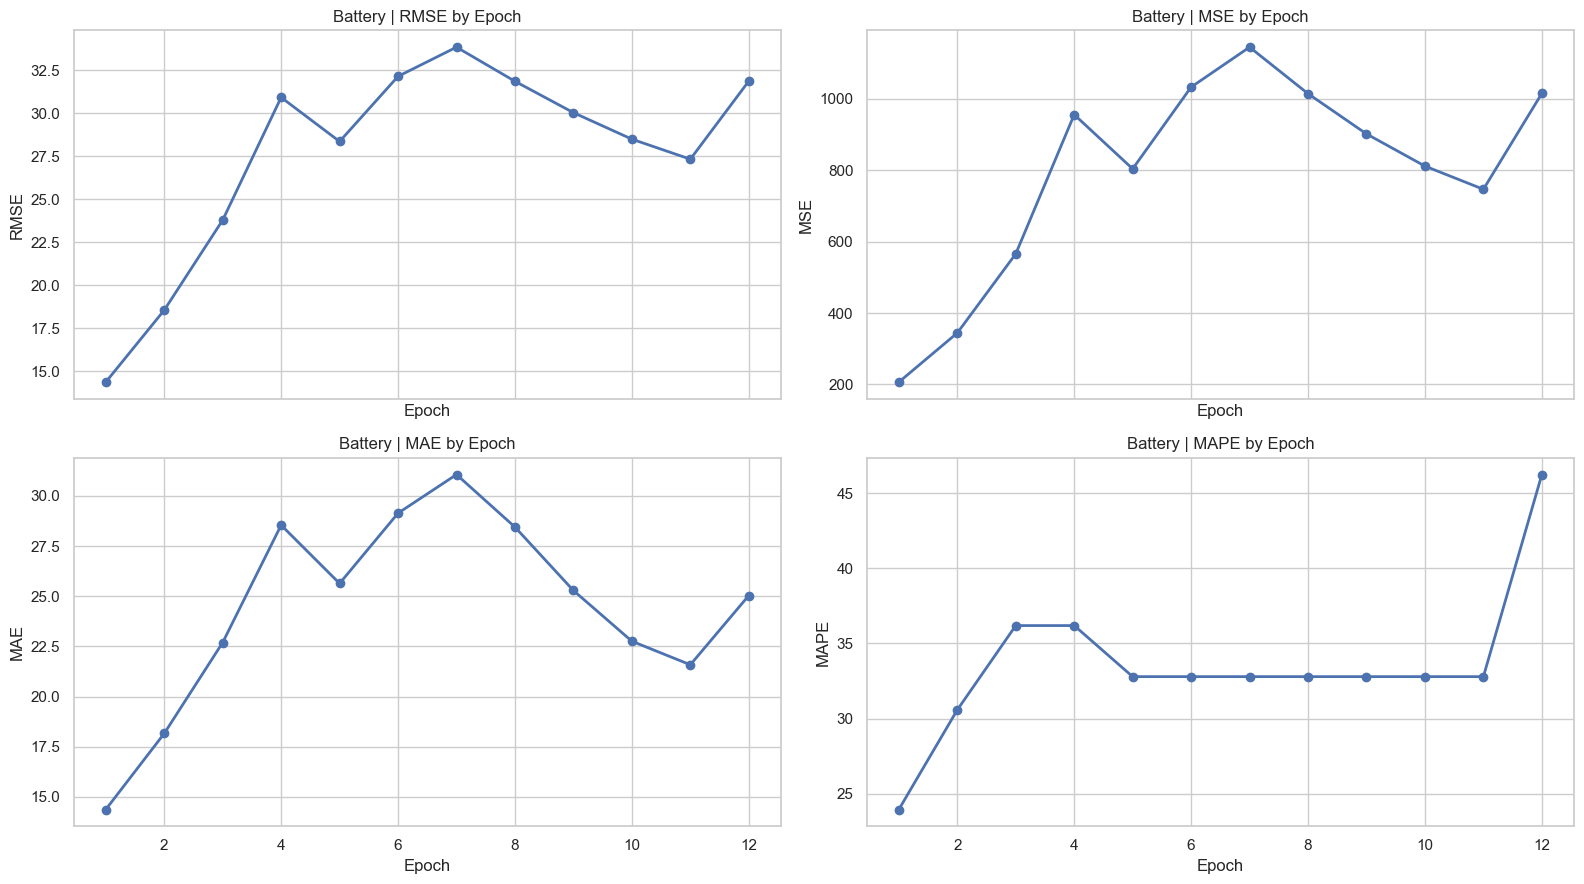

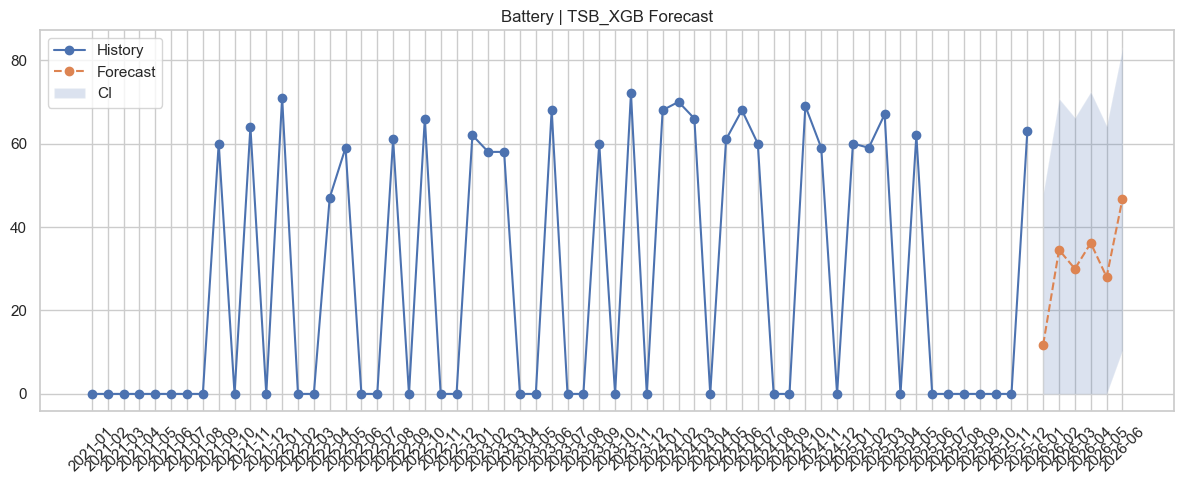

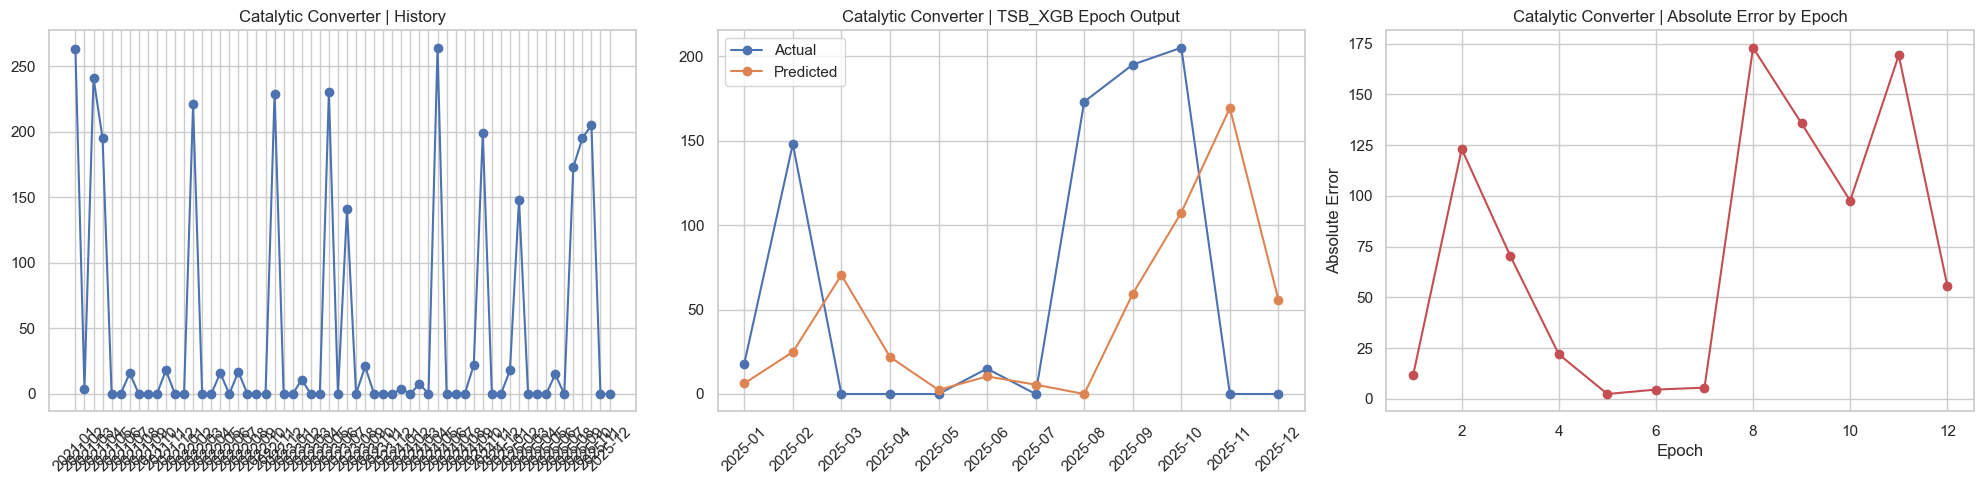

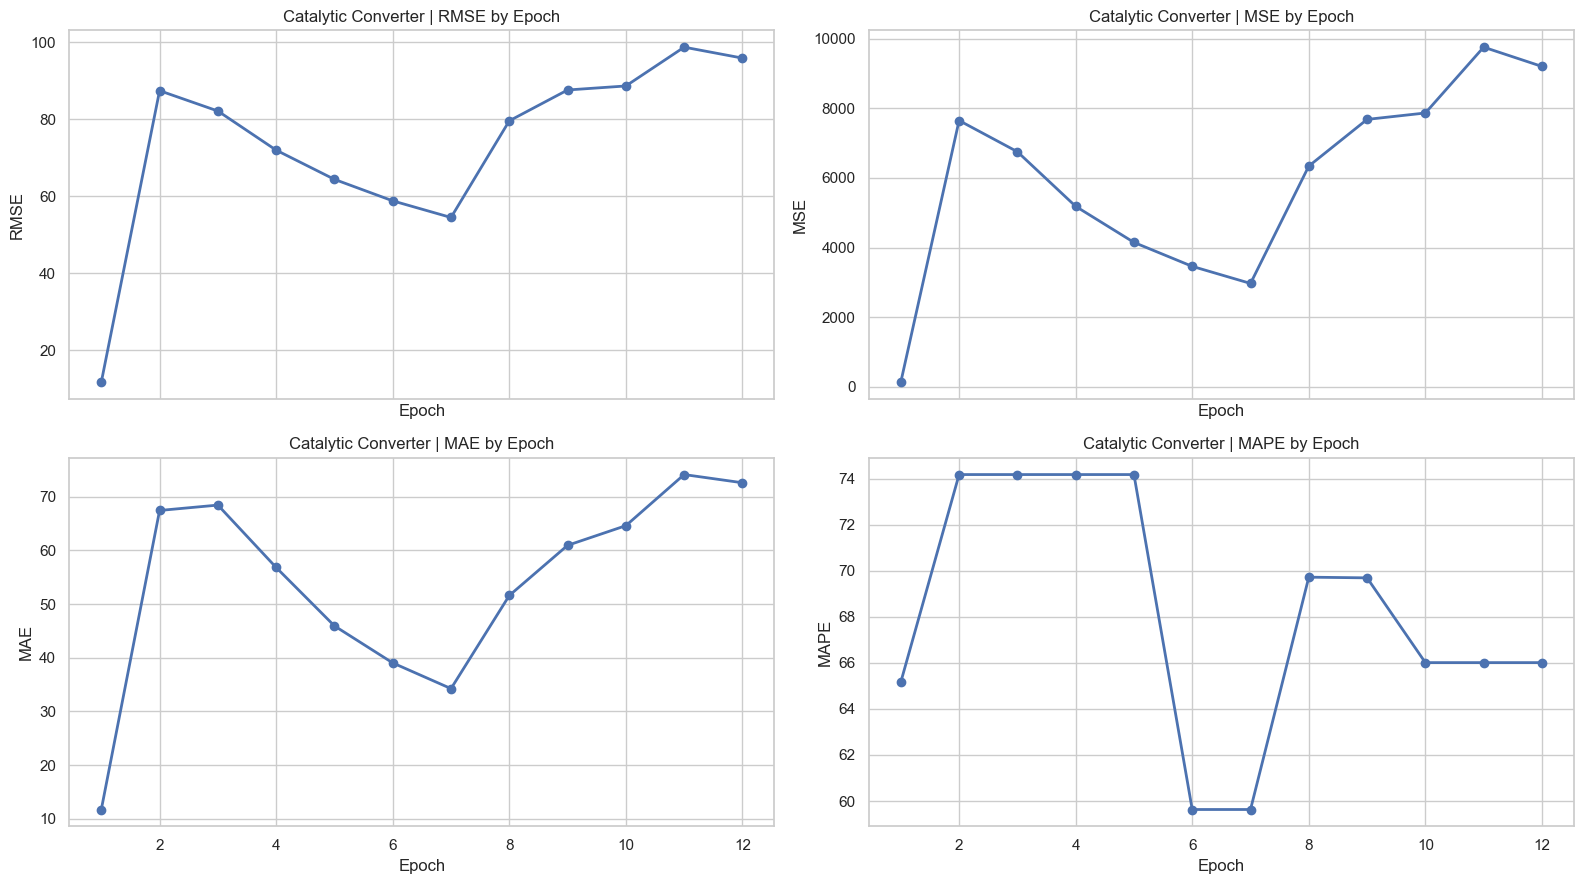

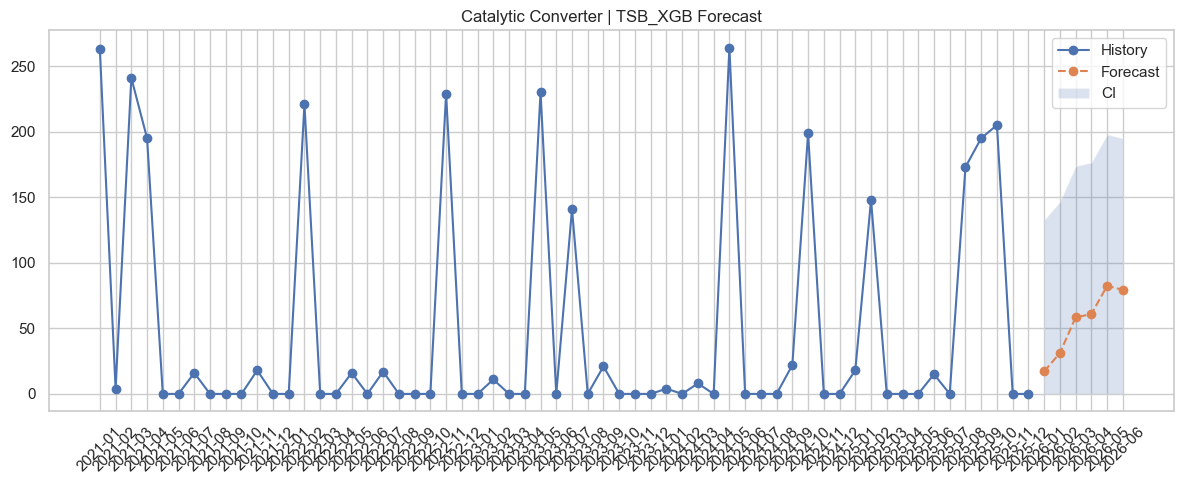

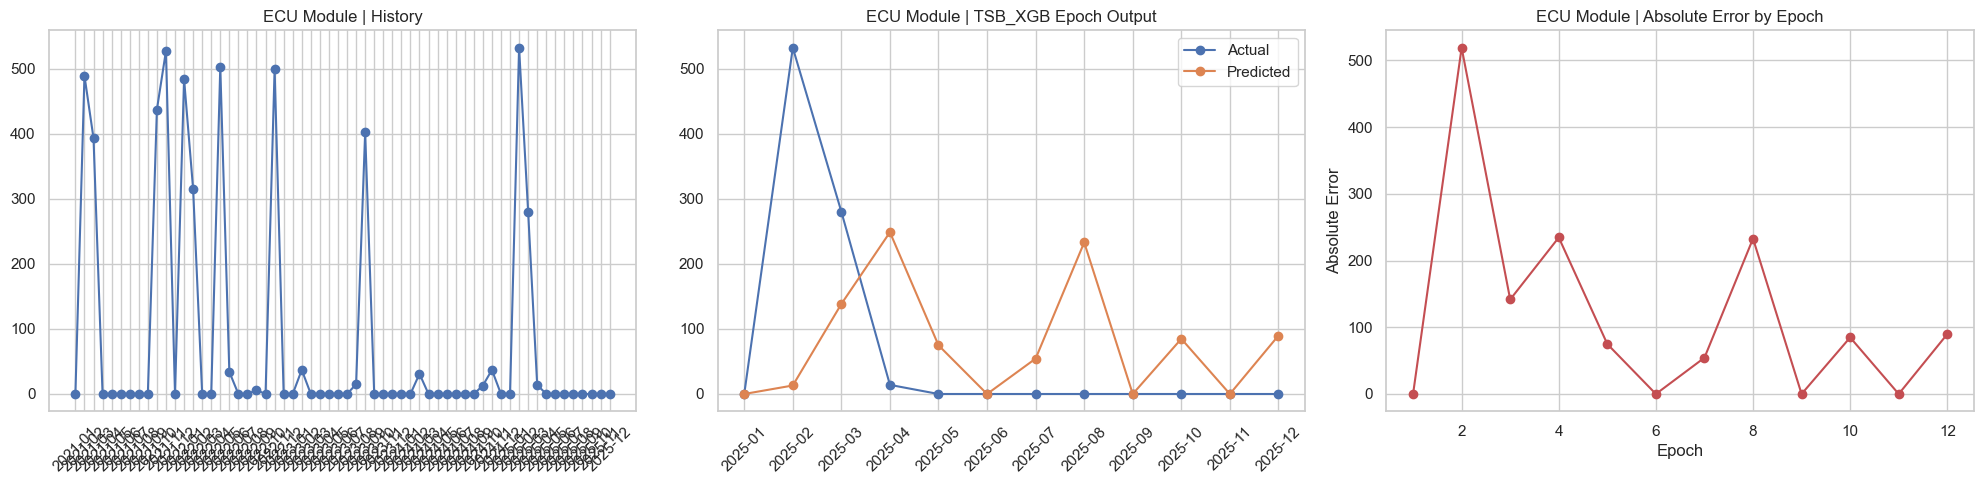

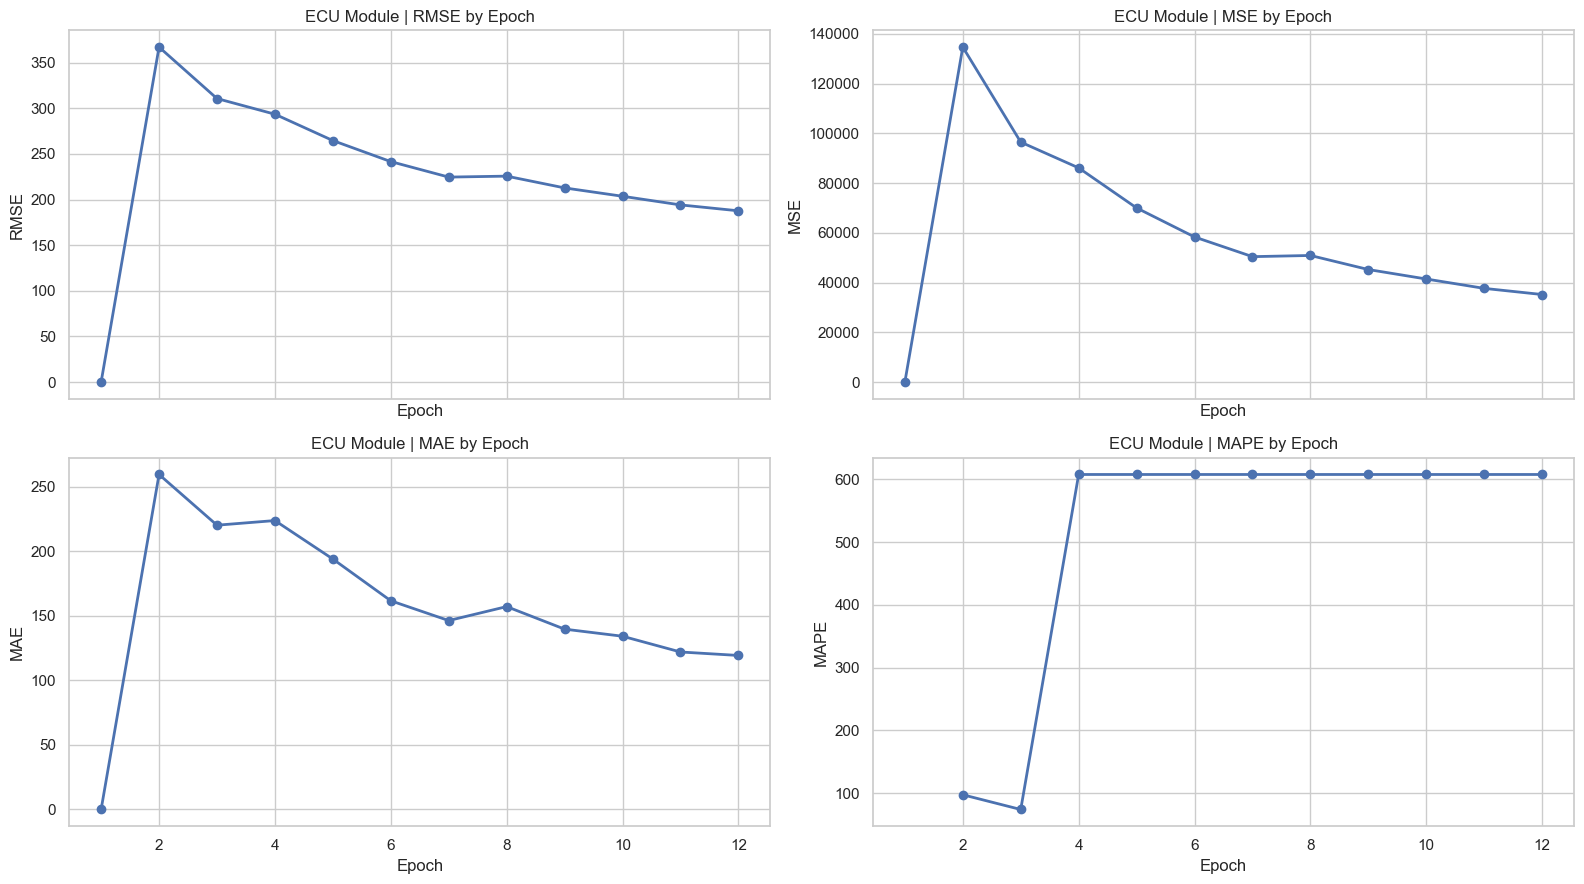

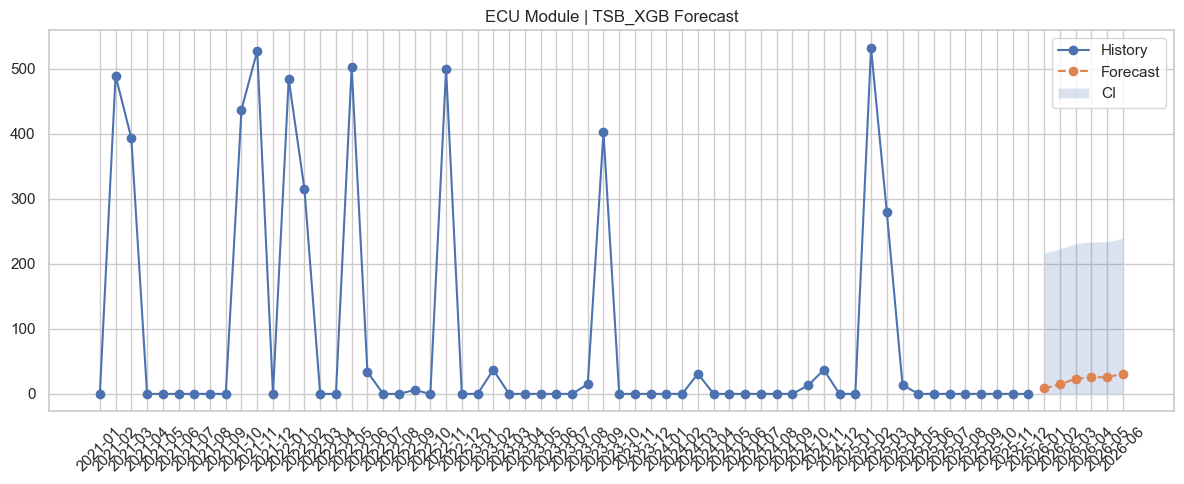

In [9]:
if training_summary_df.empty:
    raise ValueError("No products were trained. Check the dataset and minimum history settings.")

products_to_plot = (
    training_summary_df[training_summary_df["series_kind"] != "business_revenue"]["product_name"]
    .drop_duplicates()
    .tolist()
)

for product_name in products_to_plot:
    algorithm = training_summary_df.loc[training_summary_df["product_name"] == product_name, "algorithm"].iloc[0]
    product_history = monthly_sales[monthly_sales[PRODUCT_COLUMN] == product_name].sort_values("period").reset_index(drop=True)
    plot_training(
        product_name=product_name,
        model_name=algorithm,
        product_history=product_history,
        epoch_frame=epoch_results[product_name],
        forecast_rows=forecast_results[product_name].to_dict(orient="records"),
    )

## Saved Pickle Artifacts

The generated pickle files are saved per product under:

- `python/trained_models/arima_xgb/`
- `python/trained_models/tsb_xgb/`

These artifacts can be reused by the existing artifact-based sales forecasting flow.